In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Import necessary libraries
import warnings
import numpy as np
import pandas as pd
import os, random, collections, re, pickle
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn, torch.optim as optim, torch.nn.functional as F
import matplotlib.pyplot as plt

# suppress warnings
warnings.filterwarnings("ignore")

In [ ]:
import os
import re
import pandas as pd

BASE_DIR = "/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/dataset/CDFT_validation_dataset"

METAL_PATH   = os.path.join(BASE_DIR, "Metal_cluster.xlsx")
ORGANIC_PATH = os.path.join(BASE_DIR, "Organic_radicals.xlsx")
REMAIN_PATH  = os.path.join(BASE_DIR, "Remaining.xlsx")

RAW_COMBINED_CSV = os.path.join(BASE_DIR, "external_validation_raw_combined.csv")
GLOBAL_EXT_CSV   = os.path.join(BASE_DIR, "external_validation_GLOBAL.csv")
ATOM_EXT_CSV     = os.path.join(BASE_DIR, "external_validation_ATOM.csv")
MERGED_EXT_CSV   = os.path.join(BASE_DIR, "external_validation_merged_equivalent.csv")


def norm_spaces(df):
    df = df.copy()
    df.columns = [re.sub(r"\s+", " ", str(c).strip()) for c in df.columns]
    return df


def load_sheet(path):
    xls = pd.ExcelFile(path)
    sheet = xls.sheet_names[0]
    df = pd.read_excel(path, sheet_name=sheet)
    df = norm_spaces(df)
    return df


def harmonize_columns(df):
    df = df.copy()
    rename_map = {}

    if "LUMO" in df.columns and "Alpha LUMO" not in df.columns:
        rename_map["LUMO"] = "Alpha LUMO"
    if "LUMO.1" in df.columns and "Beta LUMO" not in df.columns:
        rename_map["LUMO.1"] = "Beta LUMO"

    df = df.rename(columns=rename_map)
    return df


def assert_required_columns(df, name):
    required = [
        "Radical name",
        "Hardness",
        "Electronegativity",
        "Electrophilicity",
        "Atom",
        "q(N)",
        "f-",
        "f+",
        "f0",
        "s-",
        "s+",
        "s0",
        "s+/s-",
        "s-/s+",
        "s(2)",
    ]
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"{name} is missing required columns: {missing}")


def norm_key(x):
    if pd.isna(x):
        return None
    return re.sub(r"\s+", " ", str(x).strip().lower())


metal_df   = harmonize_columns(load_sheet(METAL_PATH))
organic_df = harmonize_columns(load_sheet(ORGANIC_PATH))
remain_df  = harmonize_columns(load_sheet(REMAIN_PATH))

assert_required_columns(metal_df, "Metal_cluster")
assert_required_columns(organic_df, "Organic_radicals")
assert_required_columns(remain_df, "Remaining")

metal_df["source_set"] = "Metal_cluster"
organic_df["source_set"] = "Organic_radicals"
remain_df["source_set"] = "Remaining"

raw_df = pd.concat([metal_df, organic_df, remain_df], axis=0, ignore_index=True)
raw_df = raw_df.dropna(how="all").drop_duplicates().reset_index(drop=True)

raw_df["Radical name"] = raw_df["Radical name"].ffill()
raw_df["Radical name"] = raw_df["Radical name"].astype(str).str.strip()

if "Atom" in raw_df.columns:
    raw_df["Atom"] = raw_df["Atom"].astype(str).str.strip()

raw_df.to_csv(RAW_COMBINED_CSV, index=False)

last_global = "Electrophilicity"
idx = raw_df.columns.get_loc(last_global)

global_cols = raw_df.columns[:idx + 1].tolist()
atom_cols   = raw_df.columns[idx + 1:].tolist()

global_df_ext = raw_df[global_cols].copy()
global_df_ext["_key"] = global_df_ext["Radical name"].map(norm_key)
global_df_ext = (
    global_df_ext
    .drop_duplicates(subset="_key", keep="first")
    .drop(columns="_key")
    .reset_index(drop=True)
)

atom_df_ext = raw_df[["Radical name"] + atom_cols].copy()
atom_df_ext = atom_df_ext[atom_df_ext["Atom"].notna()].reset_index(drop=True)

external_val_df = pd.merge(
    atom_df_ext,
    global_df_ext,
    on="Radical name",
    how="inner"
)

preferred_front = [
    "Radical name",
    "Atom",
    "q(N)",
    "q(N+1)",
    "q(N-1)",
    "f-",
    "f+",
    "f0",
    "CDD",
    "Electrophilicity index",
    "Nucleophilicity index",
    "s-",
    "s+",
    "s0",
    "s+/s-",
    "s-/s+",
    "s(2)",
    "Alpha HOMO",
    "Alpha LUMO",
    "Beta HOMO",
    "Beta LUMO",
    "Hardness",
    "Electronegativity",
    "Electrophilicity",
]

remaining_cols = [c for c in external_val_df.columns if c not in preferred_front]
external_val_df = external_val_df[
    [c for c in preferred_front if c in external_val_df.columns] + remaining_cols
]

global_df_ext.to_csv(GLOBAL_EXT_CSV, index=False)
atom_df_ext.to_csv(ATOM_EXT_CSV, index=False)
external_val_df.to_csv(MERGED_EXT_CSV, index=False)

print("Saved files:")
print("  ", RAW_COMBINED_CSV)
print("  ", GLOBAL_EXT_CSV)
print("  ", ATOM_EXT_CSV)
print("  ", MERGED_EXT_CSV)

print("\nShapes:")
print("raw_df:", raw_df.shape)
print("global_df_ext:", global_df_ext.shape)
print("atom_df_ext:", atom_df_ext.shape)
print("external_val_df:", external_val_df.shape)

print("\nFinal columns:")
print(external_val_df.columns.tolist())

Saved files:
   /content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/dataset/CDFT_validation_dataset/external_validation_raw_combined.csv
   /content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/dataset/CDFT_validation_dataset/external_validation_GLOBAL.csv
   /content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/dataset/CDFT_validation_dataset/external_validation_ATOM.csv
   /content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/dataset/CDFT_validation_dataset/external_validation_merged_equivalent.csv

Shapes:
raw_df: (4603, 25)
global_df_ext: (474, 8)
atom_df_ext: (4603, 18)
external_val_df: (4603, 25)

Final columns:
['Radical name', 'Atom', 'q(N)', 'q(N+1)', 'q(N-1)', 'f-', 'f+', 'f0', 'CDD', 'Electrophilicity index', 'Nucleophilicity index', 's-', 's+', 's0', 's+/s-', 's-/s+', 's(2)', 'Alpha HOMO', 'Alpha LUMO', 'Beta HOMO', 'Beta LUMO', 'Hardness', 'Electronegativity', 'Electrophilicity', 'source_set']


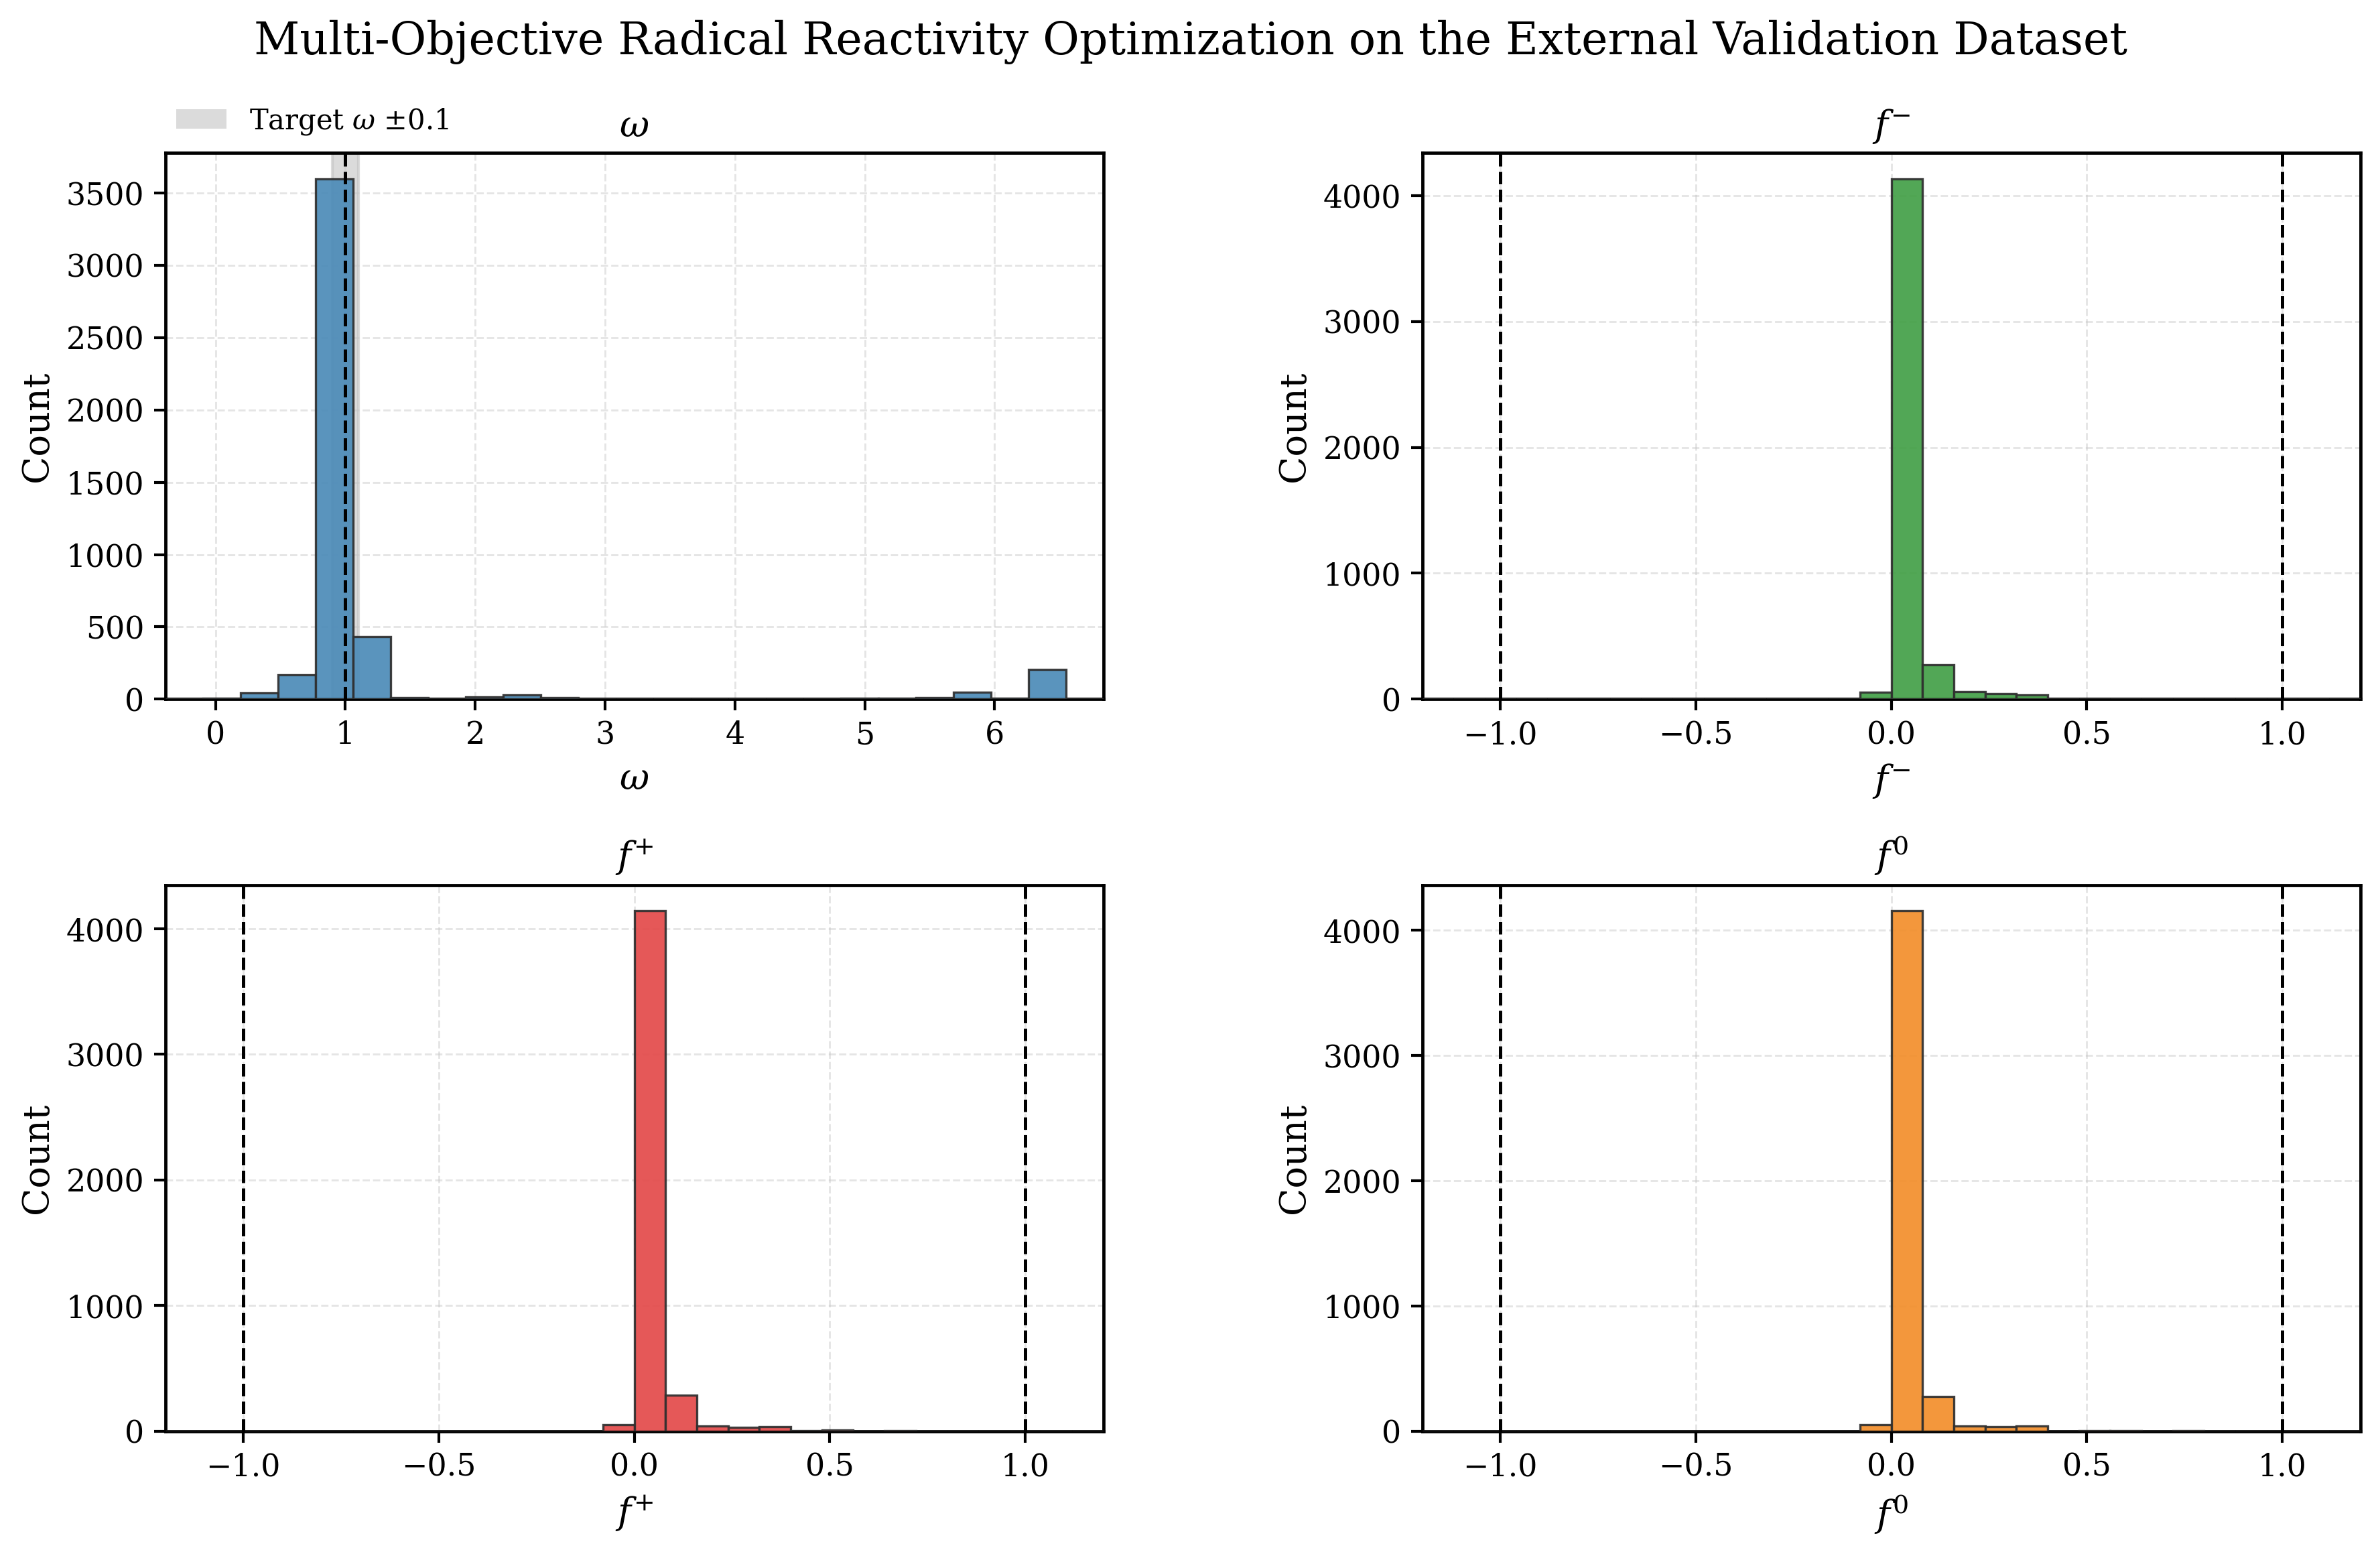


Best checkpoint metadata:
{'label': 'td3_h128_lr1e-04_gm0.99_pn0.02_pd3', 'success_rate': 0.815, 'mean_final_distance': 0.07440154582131975, 'hidden': 128}

External validation summary:
 n_rows  omega_hit_rate  fukui_hit_rate  multiobjective_hit_rate  mean_initial_omega  mean_final_omega  median_final_omega  mean_delta_omega  mean_abs_error_to_target  median_abs_error_to_target  mean_steps_taken  median_steps_taken  mean_final_f-  mean_final_f+  mean_final_f0
   4603        0.801651             1.0                 0.801651            1.428516          1.332743            1.005803         -0.095773                  0.384287                    0.013815          14.88703                 5.0       0.038615       0.038146       0.038381

Saved per-row results -> /content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/dataset/CDFT_validation_dataset/external_td3_inference_per_row_corrected.csv
Saved summary -> /content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/dataset/CDFT_va

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

BASE_DIR = "/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset"
RESULTS_DIR = os.path.join(BASE_DIR, "Results")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
OUT_DIR = os.path.join(BASE_DIR, "dataset", "CDFT_validation_dataset")

os.makedirs(PLOTS_DIR, exist_ok=True)
os.makedirs(OUT_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(RESULTS_DIR, "best_td3_checkpoint.pth")

EXT_VAL_CSV = os.path.join(
    BASE_DIR,
    "dataset",
    "CDFT_validation_dataset",
    "external_validation_merged_equivalent.csv"
)

OUT_CSV = os.path.join(
    OUT_DIR,
    "external_td3_inference_per_row_corrected.csv"
)

OUT_SUMMARY_CSV = os.path.join(
    OUT_DIR,
    "external_td3_inference_summary_corrected.csv"
)

OUT_PANEL_PNG = os.path.join(
    PLOTS_DIR,
    "external_validation_multiobjective_histogram_panel_publication.png"
)

OUT_PANEL_PDF = os.path.join(
    PLOTS_DIR,
    "external_validation_multiobjective_histogram_panel_publication.pdf"
)

STATE_COLUMNS = [
    "Electronegativity", "Hardness", "Electrophilicity", "q(N)",
    "f-", "f+", "f0", "s-", "s+", "s0", "s+/s-", "s-/s+", "s(2)"
]

OMEGA_COL = "Electrophilicity"

TARGET_OMEGA = 1.0
OMEGA_TOL = 0.10

POS_CLIP = 0.05
NEG_CLIP = 0.05
MAX_STEPS = 50

F_BOUNDS = {
    "f-": (-1.0, 1.0),
    "f+": (-1.0, 1.0),
    "f0": (-1.0, 1.0),
}


def _safe_ratio(num, den, eps=1e-8):
    n = np.asarray(num, dtype=np.float64)
    d = np.asarray(den, dtype=np.float64)
    return n / (np.sign(d) * np.maximum(np.abs(d), eps))


def _ensure_series(x, index):
    if isinstance(x, pd.Series):
        return x.reindex(index)
    if isinstance(x, dict):
        return pd.Series(x).reindex(index)
    if isinstance(x, np.ndarray):
        return pd.Series(x, index=index)
    return pd.Series(x, index=index)


def mlp(sizes, act_last=None):
    layers = []
    for i in range(len(sizes) - 2):
        layers += [nn.Linear(sizes[i], sizes[i + 1]), nn.ReLU()]
    layers.append(nn.Linear(sizes[-2], sizes[-1]))
    if act_last == "tanh":
        layers.append(nn.Tanh())
    return nn.Sequential(*layers)


class Actor(nn.Module):
    def __init__(self, state_dim, hidden):
        super().__init__()
        self.body = mlp([state_dim, hidden, hidden, 1], act_last="tanh")

    def forward(self, s):
        return self.body(s).squeeze(1)


def load_best_checkpoint(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)

    actor_state = ckpt["actor"]
    hparams = ckpt["hparams"]
    scaler = ckpt["scaler"]

    mu = _ensure_series(scaler["mu"], STATE_COLUMNS).astype(float)
    sd = _ensure_series(scaler["sd"], STATE_COLUMNS).astype(float).replace(0.0, 1.0)

    hidden = int(hparams["hidden"])

    return actor_state, hidden, mu, sd, ckpt


def preprocess_external_dataframe(df, train_mu, train_sd):
    df = df.copy()

    for c in STATE_COLUMNS:
        if c not in df.columns:
            df[c] = np.nan

    if "s+/s-" not in df.columns:
        df["s+/s-"] = _safe_ratio(df.get("s+", 0.0), df.get("s-", 1.0))

    if "s-/s+" not in df.columns:
        df["s-/s+"] = _safe_ratio(df.get("s-", 0.0), df.get("s+", 1.0))

    df[STATE_COLUMNS] = df[STATE_COLUMNS].ffill().bfill()

    df["f-"] = df["f-"].clip(-1.0, 1.0)
    df["f+"] = df["f+"].clip(-1.0, 1.0)
    df["f0"] = df["f0"].clip(-1.0, 1.0)
    df[OMEGA_COL] = df[OMEGA_COL].clip(0.0, 6.5)

    df_scaled = (df[STATE_COLUMNS] - train_mu) / train_sd

    df_scaled["_omega_unscaled"] = df[OMEGA_COL].astype(np.float32).values
    df_scaled["_omega_mu"] = float(train_mu[OMEGA_COL])
    df_scaled["_omega_sd"] = float(train_sd[OMEGA_COL]) if float(train_sd[OMEGA_COL]) != 0 else 1.0

    return df, df_scaled.reset_index(drop=True)


@torch.no_grad()
def rollout_single_row(
    actor,
    state_vec,
    omega_mu,
    omega_sd,
    max_steps=50,
    pos_clip=0.05,
    neg_clip=0.05,
    target_omega=1.0,
    success_thr=0.02,
    omega_clip=(0.0, 6.5),
    high_omega_terminate=5.0,
):
    device = next(actor.parameters()).device
    state = state_vec.astype(np.float32).copy()

    initial_omega = float(omega_sd * state[2] + omega_mu)
    final_omega = initial_omega
    steps_taken = 0

    omega_path = [initial_omega]

    for step_idx in range(max_steps):
        st = torch.from_numpy(state).float().unsqueeze(0).to(device)
        raw = actor(st).item()

        action = raw * pos_clip if raw >= 0 else raw * neg_clip

        prev_omega = float(omega_sd * state[2] + omega_mu)
        new_omega = float(np.clip(prev_omega + action, omega_clip[0], omega_clip[1]))

        state[2] = (new_omega - omega_mu) / (omega_sd if omega_sd != 0 else 1.0)

        final_omega = new_omega
        steps_taken = step_idx + 1
        omega_path.append(final_omega)

        if final_omega >= high_omega_terminate:
            break

        if abs(final_omega - target_omega) <= success_thr:
            break

    return {
        "initial_omega": initial_omega,
        "final_omega": final_omega,
        "delta_omega": final_omega - initial_omega,
        "abs_error_to_target": abs(final_omega - target_omega),
        "omega_hit": abs(final_omega - target_omega) <= OMEGA_TOL,
        "steps_taken": steps_taken,
        "omega_path": omega_path,
    }


def make_results_dataframe(raw_df, scaled_df, actor, omega_mu, omega_sd):
    id_cols = [c for c in ["Radical name", "Atom"] if c in raw_df.columns]

    rows = []

    for i in range(len(raw_df)):
        raw_row = raw_df.iloc[i]
        scaled_row = scaled_df.iloc[i]

        state_vec = scaled_row[STATE_COLUMNS].values.astype(np.float32)

        out = rollout_single_row(
            actor=actor,
            state_vec=state_vec,
            omega_mu=omega_mu,
            omega_sd=omega_sd,
            max_steps=MAX_STEPS,
            pos_clip=POS_CLIP,
            neg_clip=NEG_CLIP,
            target_omega=TARGET_OMEGA,
            success_thr=0.02,
        )

        row = {"row_index": i}

        for c in id_cols:
            row[c] = raw_row[c]

        row["dataset_omega"] = float(raw_row[OMEGA_COL]) if OMEGA_COL in raw_row.index else np.nan
        row["dataset_f-"] = float(raw_row["f-"]) if "f-" in raw_row.index else np.nan
        row["dataset_f+"] = float(raw_row["f+"]) if "f+" in raw_row.index else np.nan
        row["dataset_f0"] = float(raw_row["f0"]) if "f0" in raw_row.index else np.nan

        row["initial_omega"] = out["initial_omega"]
        row["final_omega"] = out["final_omega"]
        row["delta_omega"] = out["delta_omega"]
        row["abs_error_to_target"] = out["abs_error_to_target"]
        row["omega_hit"] = out["omega_hit"]
        row["steps_taken"] = out["steps_taken"]

        row["initial_f-"] = float(raw_row["f-"]) if "f-" in raw_row.index else np.nan
        row["initial_f+"] = float(raw_row["f+"]) if "f+" in raw_row.index else np.nan
        row["initial_f0"] = float(raw_row["f0"]) if "f0" in raw_row.index else np.nan

        row["final_f-"] = float(raw_row["f-"]) if "f-" in raw_row.index else np.nan
        row["final_f+"] = float(raw_row["f+"]) if "f+" in raw_row.index else np.nan
        row["final_f0"] = float(raw_row["f0"]) if "f0" in raw_row.index else np.nan

        row["omega_path"] = ";".join([f"{x:.6f}" for x in out["omega_path"]])

        fukui_hit = True

        for k, (lo, hi) in F_BOUNDS.items():
            val = row[f"final_{k}"]
            if pd.isna(val) or not (lo <= val <= hi):
                fukui_hit = False
                break

        row["fukui_hit"] = fukui_hit
        row["multiobjective_hit"] = bool(row["omega_hit"] and row["fukui_hit"])

        rows.append(row)

    return pd.DataFrame(rows)


def make_summary_dataframe(results_df):
    summary = {
        "n_rows": int(len(results_df)),
        "omega_hit_rate": float(results_df["omega_hit"].mean()),
        "fukui_hit_rate": float(results_df["fukui_hit"].mean()),
        "multiobjective_hit_rate": float(results_df["multiobjective_hit"].mean()),
        "mean_initial_omega": float(results_df["initial_omega"].mean()),
        "mean_final_omega": float(results_df["final_omega"].mean()),
        "median_final_omega": float(results_df["final_omega"].median()),
        "mean_delta_omega": float(results_df["delta_omega"].mean()),
        "mean_abs_error_to_target": float(results_df["abs_error_to_target"].mean()),
        "median_abs_error_to_target": float(results_df["abs_error_to_target"].median()),
        "mean_steps_taken": float(results_df["steps_taken"].mean()),
        "median_steps_taken": float(results_df["steps_taken"].median()),
        "mean_final_f-": float(results_df["final_f-"].mean()),
        "mean_final_f+": float(results_df["final_f+"].mean()),
        "mean_final_f0": float(results_df["final_f0"].mean()),
    }

    return pd.DataFrame([summary])


def _get_omega_xlim(values):
    values = pd.Series(values).dropna().astype(float).values

    if len(values) == 0:
        return 0.0, 1.5

    lo = float(np.nanmin(values))
    hi = float(np.nanmax(values))

    lo = min(lo, TARGET_OMEGA - 0.20)
    hi = max(hi, TARGET_OMEGA + 0.20)

    span = hi - lo
    lo = lo - 0.06 * span
    hi = hi + 0.06 * span

    return lo, hi


def make_external_validation_panel(results_df, out_png, out_pdf):
    plt.rcParams.update({
        "font.family": "DejaVu Serif",
        "font.size": 12,
        "axes.titlesize": 13,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
        "figure.titlesize": 16,
        "axes.linewidth": 1.15,
        "xtick.major.width": 1.0,
        "ytick.major.width": 1.0,
        "xtick.major.size": 4.0,
        "ytick.major.size": 4.0,
        "mathtext.fontset": "dejavuserif",
    })

    omega_values = results_df["final_omega"].dropna().astype(float)
    fminus_values = results_df["final_f-"].dropna().astype(float)
    fplus_values = results_df["final_f+"].dropna().astype(float)
    fzero_values = results_df["final_f0"].dropna().astype(float)

    fig, axes = plt.subplots(
        2,
        2,
        figsize=(12.0, 7.8),
        dpi=300
    )

    fig.suptitle(
        "Multi-Objective Radical Reactivity Optimization on the External Validation Dataset",
        y=0.985,
        fontsize=16
    )

    colors = {
        "omega": "#4C8BB8",
        "fminus": "#43A047",
        "fplus": "#E34A4A",
        "fzero": "#F28E2B",
        "band": "#BFBFBF",
        "edge": "#2F2F2F",
        "grid": "#C6C6C6",
    }

    omega_xlim = _get_omega_xlim(omega_values)
    omega_bins = np.linspace(omega_xlim[0], omega_xlim[1], 26)

    f_xlim = (-1.2, 1.2)
    f_bins = np.linspace(f_xlim[0], f_xlim[1], 31)

    ax = axes[0, 0]

    ax.axvspan(
        TARGET_OMEGA - OMEGA_TOL,
        TARGET_OMEGA + OMEGA_TOL,
        color=colors["band"],
        alpha=0.55,
        zorder=1
    )

    ax.hist(
        omega_values,
        bins=omega_bins,
        color=colors["omega"],
        edgecolor=colors["edge"],
        linewidth=0.8,
        alpha=0.92,
        zorder=3
    )

    ax.axvline(
        TARGET_OMEGA,
        color="black",
        linestyle="--",
        linewidth=1.2,
        zorder=4
    )

    ax.set_title(r"$\omega$")
    ax.set_xlabel(r"$\omega$")
    ax.set_ylabel("Count")
    ax.set_xlim(omega_xlim)

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.7,
        alpha=0.45,
        color=colors["grid"],
        zorder=0
    )

    ax.legend(
        handles=[
            Patch(
                facecolor=colors["band"],
                edgecolor="none",
                alpha=0.55,
                label=r"Target $\omega$ ±0.1"
            )
        ],
        loc="lower left",
        bbox_to_anchor=(0.00, 1.01),
        frameon=False,
        borderaxespad=0.0,
        handlelength=1.8
    )

    ax = axes[0, 1]

    ax.hist(
        fminus_values,
        bins=f_bins,
        color=colors["fminus"],
        edgecolor=colors["edge"],
        linewidth=0.8,
        alpha=0.92,
        zorder=3
    )

    ax.axvline(-1.0, color="black", linestyle="--", linewidth=1.2, zorder=4)
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2, zorder=4)

    ax.set_title(r"$f^{-}$")
    ax.set_xlabel(r"$f^{-}$")
    ax.set_ylabel("Count")
    ax.set_xlim(f_xlim)

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.7,
        alpha=0.45,
        color=colors["grid"],
        zorder=0
    )

    ax = axes[1, 0]

    ax.hist(
        fplus_values,
        bins=f_bins,
        color=colors["fplus"],
        edgecolor=colors["edge"],
        linewidth=0.8,
        alpha=0.92,
        zorder=3
    )

    ax.axvline(-1.0, color="black", linestyle="--", linewidth=1.2, zorder=4)
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2, zorder=4)

    ax.set_title(r"$f^{+}$")
    ax.set_xlabel(r"$f^{+}$")
    ax.set_ylabel("Count")
    ax.set_xlim(f_xlim)

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.7,
        alpha=0.45,
        color=colors["grid"],
        zorder=0
    )

    ax = axes[1, 1]

    ax.hist(
        fzero_values,
        bins=f_bins,
        color=colors["fzero"],
        edgecolor=colors["edge"],
        linewidth=0.8,
        alpha=0.92,
        zorder=3
    )

    ax.axvline(-1.0, color="black", linestyle="--", linewidth=1.2, zorder=4)
    ax.axvline(1.0, color="black", linestyle="--", linewidth=1.2, zorder=4)

    ax.set_title(r"$f^{0}$")
    ax.set_xlabel(r"$f^{0}$")
    ax.set_ylabel("Count")
    ax.set_xlim(f_xlim)

    ax.grid(
        True,
        linestyle="--",
        linewidth=0.7,
        alpha=0.45,
        color=colors["grid"],
        zorder=0
    )

    for ax in axes.ravel():
        for spine in ax.spines.values():
            spine.set_linewidth(1.15)

        ax.tick_params(axis="both", which="major", direction="out")

    fig.subplots_adjust(
        left=0.075,
        right=0.985,
        bottom=0.085,
        top=0.900,
        wspace=0.34,
        hspace=0.34
    )

    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    fig.savefig(out_pdf, dpi=300, bbox_inches="tight")

    plt.show()


def main():
    raw_ext = pd.read_csv(EXT_VAL_CSV)

    actor_state, hidden, train_mu, train_sd, ckpt = load_best_checkpoint(CHECKPOINT_PATH)

    raw_ext_processed, ext_scaled = preprocess_external_dataframe(
        raw_ext,
        train_mu,
        train_sd
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    actor = Actor(
        state_dim=len(STATE_COLUMNS),
        hidden=hidden
    ).to(device)

    actor.load_state_dict(actor_state)
    actor.eval()

    omega_mu = float(train_mu[OMEGA_COL])
    omega_sd = float(train_sd[OMEGA_COL]) if float(train_sd[OMEGA_COL]) != 0 else 1.0

    results_df = make_results_dataframe(
        raw_df=raw_ext_processed,
        scaled_df=ext_scaled,
        actor=actor,
        omega_mu=omega_mu,
        omega_sd=omega_sd,
    )

    summary_df = make_summary_dataframe(results_df)

    results_df.to_csv(OUT_CSV, index=False)
    summary_df.to_csv(OUT_SUMMARY_CSV, index=False)

    make_external_validation_panel(
        results_df=results_df,
        out_png=OUT_PANEL_PNG,
        out_pdf=OUT_PANEL_PDF
    )

    print("\nBest checkpoint metadata:")
    print({
        "label": ckpt.get("meta", {}).get("label", None),
        "success_rate": ckpt.get("meta", {}).get("success_rate", None),
        "mean_final_distance": ckpt.get("meta", {}).get("mean_final_distance", None),
        "hidden": hidden,
    })

    print("\nExternal validation summary:")
    print(summary_df.to_string(index=False))

    print(f"\nSaved per-row results -> {OUT_CSV}")
    print(f"Saved summary -> {OUT_SUMMARY_CSV}")
    print(f"Saved publication panel PNG -> {OUT_PANEL_PNG}")
    print(f"Saved publication panel PDF -> {OUT_PANEL_PDF}")


if __name__ == "__main__":
    main()

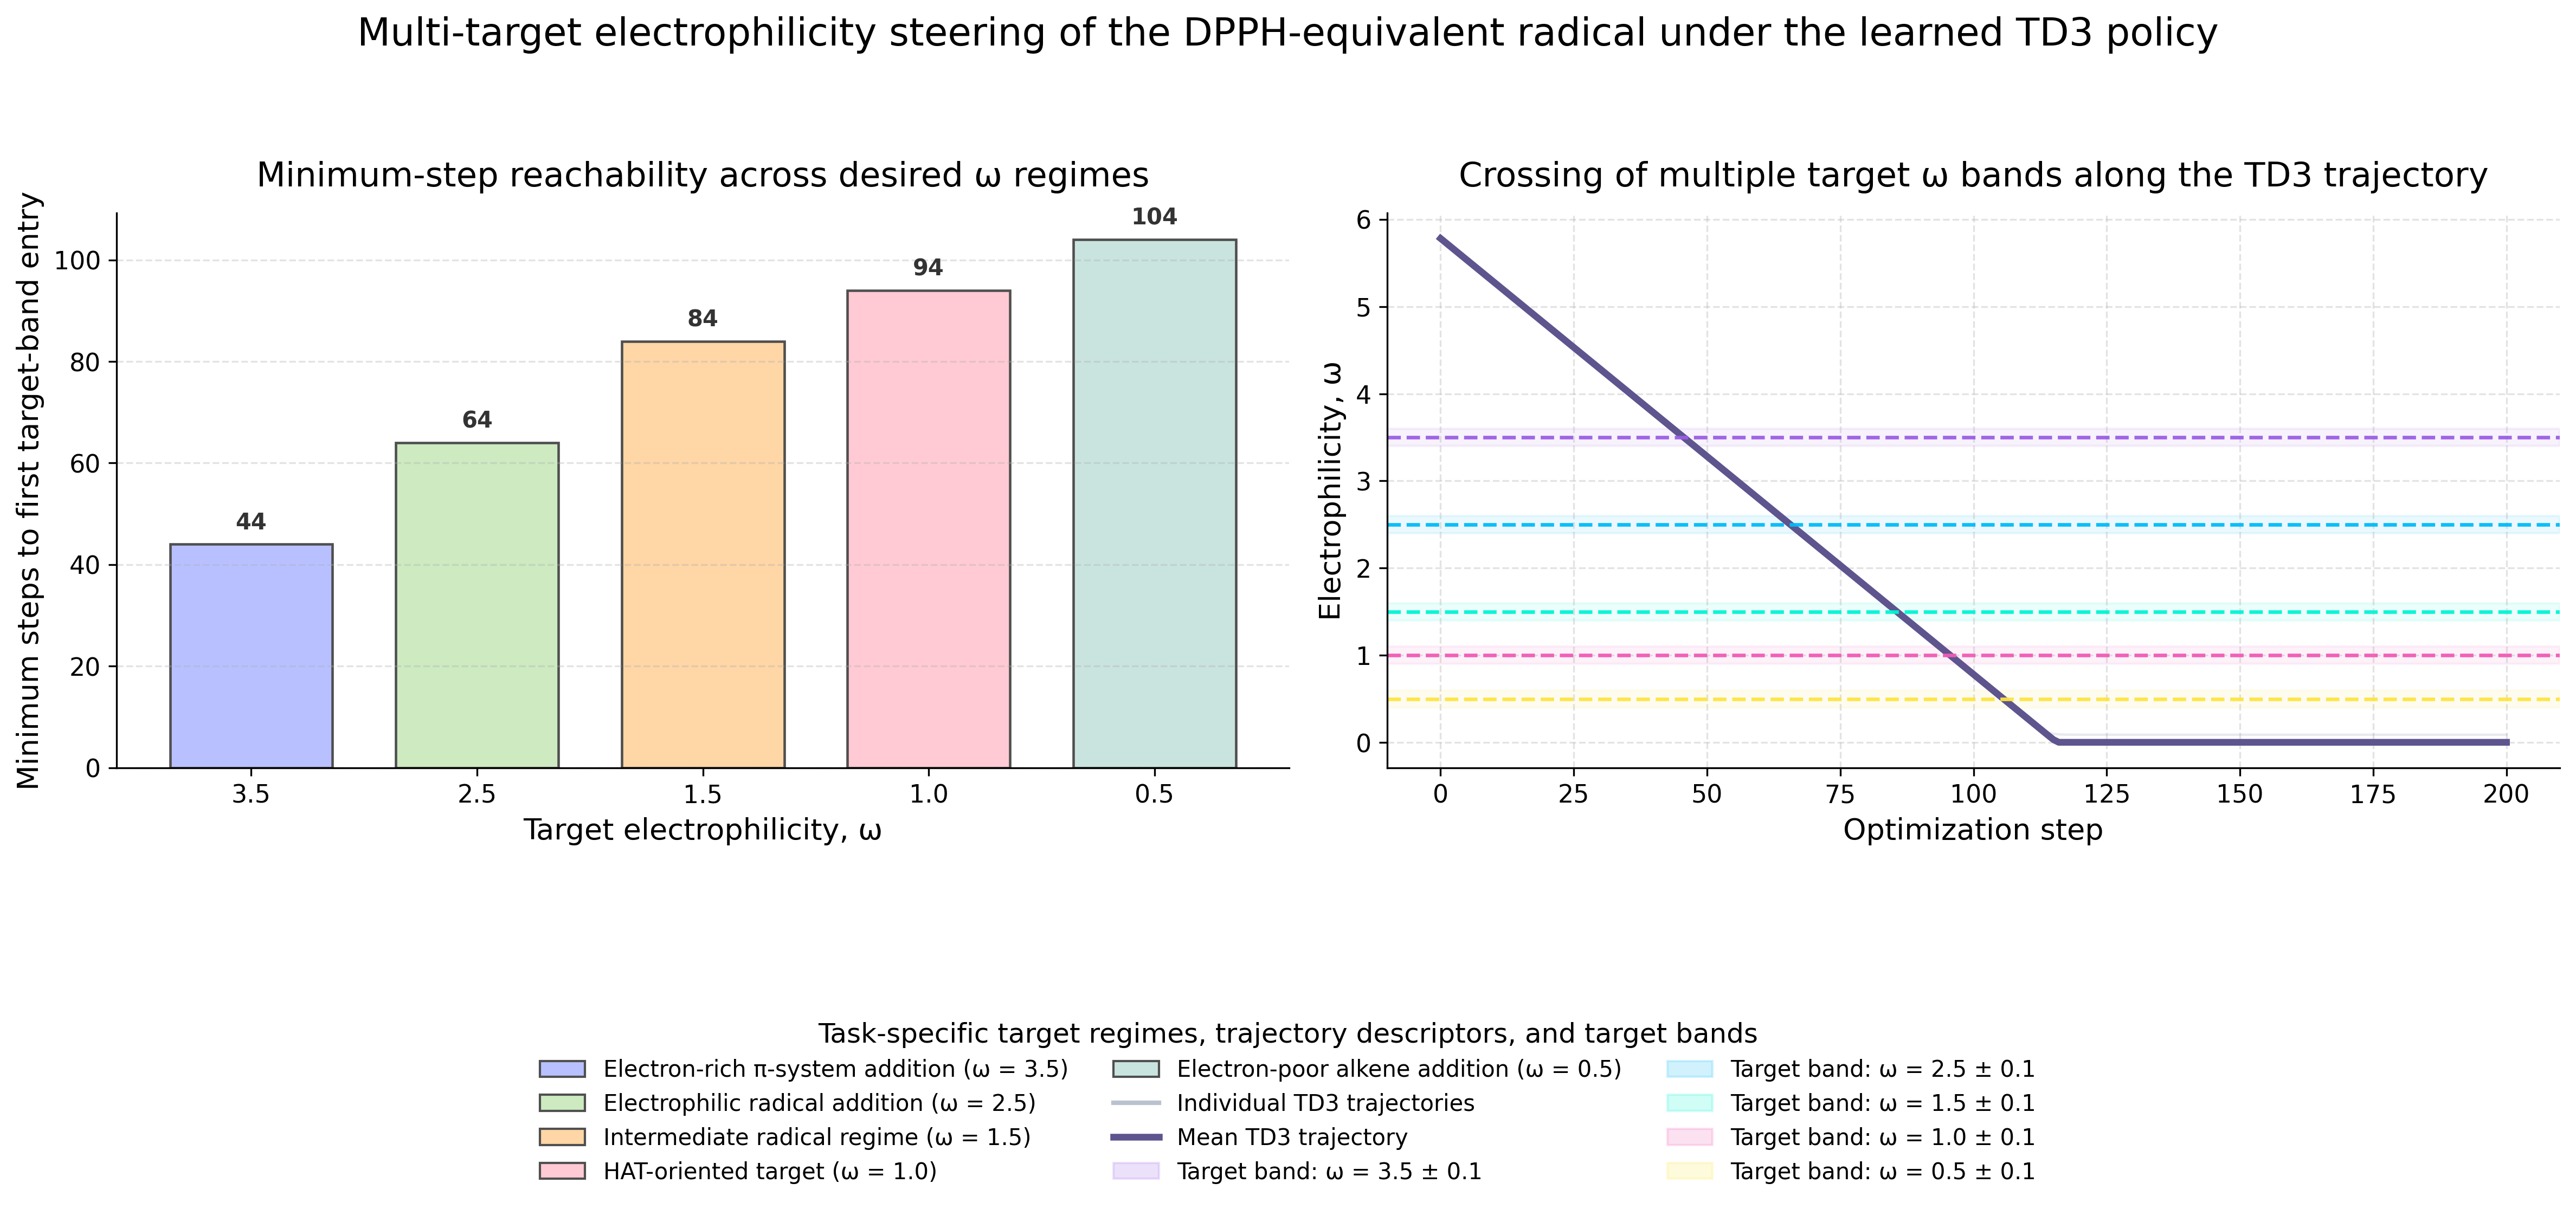


Best checkpoint metadata:
{'label': 'td3_h128_lr1e-04_gm0.99_pn0.02_pd3', 'success_rate': 0.815, 'mean_final_distance': 0.07440154582131975, 'hidden': 128}

Trajectory table:
 row_index_within_match                                   Radical name  Atom  dataset_omega  initial_omega  final_omega_at_cap
                      0 22-diphenyl-1-246-trinitrophenyl_hydrazin-1-yl  1(C)        5.78108        5.78108            0.000000
                      1 22-diphenyl-1-246-trinitrophenyl_hydrazin-1-yl  2(C)        5.78108        5.78108            0.000000
                      2 22-diphenyl-1-246-trinitrophenyl_hydrazin-1-yl  3(C)        5.78108        5.78108            0.000000
                      3 22-diphenyl-1-246-trinitrophenyl_hydrazin-1-yl  4(C)        5.78108        5.78108            0.000000
                      4 22-diphenyl-1-246-trinitrophenyl_hydrazin-1-yl  5(C)        5.78108        5.78108            0.000000
                      5 22-diphenyl-1-246-trinitrophenyl_hydra

In [ ]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D

BASE_DIR = "/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset"
RESULTS_DIR = os.path.join(BASE_DIR, "Results")
OUT_DIR = os.path.join(BASE_DIR, "dataset", "CDFT_validation_dataset")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(OUT_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

CHECKPOINT_PATH = os.path.join(RESULTS_DIR, "best_td3_checkpoint.pth")
EXT_VAL_CSV = os.path.join(
    BASE_DIR,
    "dataset",
    "CDFT_validation_dataset",
    "external_validation_merged_equivalent.csv"
)

TARGET_RADICAL = "22-diphenyl-1-246-trinitrophenyl_hydrazin-1-yl"

OUT_RESULTS_CSV = os.path.join(
    OUT_DIR,
    "target_radical_td3_multi_target_omega_analysis.csv"
)
OUT_SUMMARY_CSV = os.path.join(
    OUT_DIR,
    "target_radical_td3_multi_target_omega_summary.csv"
)
OUT_FIG = os.path.join(
    PLOTS_DIR,
    "target_radical_td3_multi_target_omega_subplots_publication_fixed_legend.png"
)

STATE_COLUMNS = [
    "Electronegativity", "Hardness", "Electrophilicity", "q(N)",
    "f-", "f+", "f0", "s-", "s+", "s0", "s+/s-", "s-/s+", "s(2)"
]

OMEGA_COL = "Electrophilicity"
POS_CLIP = 0.05
NEG_CLIP = 0.05
MAX_ANALYSIS_STEPS = 200
OMEGA_TOL = 0.10

TARGETS = [
    {"label": "Electron-rich π-system addition", "target_omega": 3.5},
    {"label": "Electrophilic radical addition", "target_omega": 2.5},
    {"label": "Intermediate radical regime", "target_omega": 1.5},
    {"label": "HAT-oriented target", "target_omega": 1.0},
    {"label": "Electron-poor alkene addition", "target_omega": 0.5},
]

PASTEL_BAR_COLORS = ["#B8C0FF", "#CDEAC0", "#FFD6A5", "#FFCAD4", "#C9E4DE"]
TRAJECTORY_COLOR = "#8E9AAF"
MEAN_TRAJECTORY_COLOR = "#5E548E"
TARGET_LINE_COLORS = ["#9B5DE5", "#00BBF9", "#00F5D4", "#F15BB5", "#FEE440"]


def _safe_ratio(num, den, eps=1e-8):
    n = np.asarray(num, dtype=np.float64)
    d = np.asarray(den, dtype=np.float64)
    return n / (np.sign(d) * np.maximum(np.abs(d), eps))


def _ensure_series(x, index):
    if isinstance(x, pd.Series):
        return x.reindex(index)
    if isinstance(x, dict):
        return pd.Series(x).reindex(index)
    if isinstance(x, np.ndarray):
        return pd.Series(x, index=index)
    return pd.Series(x, index=index)


def norm_name(x):
    if pd.isna(x):
        return None
    return " ".join(str(x).strip().lower().split())


def mlp(sizes, act_last=None):
    layers = []
    for i in range(len(sizes) - 2):
        layers += [nn.Linear(sizes[i], sizes[i + 1]), nn.ReLU()]
    layers.append(nn.Linear(sizes[-2], sizes[-1]))
    if act_last == "tanh":
        layers.append(nn.Tanh())
    return nn.Sequential(*layers)


class Actor(nn.Module):
    def __init__(self, state_dim, hidden):
        super().__init__()
        self.body = mlp([state_dim, hidden, hidden, 1], act_last="tanh")

    def forward(self, s):
        return self.body(s).squeeze(1)


def load_best_checkpoint(checkpoint_path):
    ckpt = torch.load(checkpoint_path, map_location="cpu", weights_only=False)

    actor_state = ckpt["actor"]
    hparams = ckpt["hparams"]
    scaler = ckpt["scaler"]

    mu = _ensure_series(scaler["mu"], STATE_COLUMNS).astype(float)
    sd = _ensure_series(scaler["sd"], STATE_COLUMNS).astype(float).replace(0.0, 1.0)

    hidden = int(hparams["hidden"])
    return actor_state, hidden, mu, sd, ckpt


def preprocess_external_dataframe(df, train_mu, train_sd):
    df = df.copy()

    for c in STATE_COLUMNS:
        if c not in df.columns:
            df[c] = np.nan

    if "s+/s-" not in df.columns:
        df["s+/s-"] = _safe_ratio(df.get("s+", 0.0), df.get("s-", 1.0))
    if "s-/s+" not in df.columns:
        df["s-/s+"] = _safe_ratio(df.get("s-", 0.0), df.get("s+", 1.0))

    df[STATE_COLUMNS] = df[STATE_COLUMNS].ffill().bfill()
    df["f-"] = df["f-"].clip(-1.0, 1.0)
    df["f+"] = df["f+"].clip(-1.0, 1.0)
    df["f0"] = df["f0"].clip(-1.0, 1.0)
    df[OMEGA_COL] = df[OMEGA_COL].clip(0.0, 6.5)

    df_scaled = (df[STATE_COLUMNS] - train_mu) / train_sd
    df_scaled["_omega_unscaled"] = df[OMEGA_COL].astype(np.float32).values
    df_scaled["_omega_mu"] = float(train_mu[OMEGA_COL])
    df_scaled["_omega_sd"] = float(train_sd[OMEGA_COL]) if float(train_sd[OMEGA_COL]) != 0 else 1.0

    return df.reset_index(drop=True), df_scaled.reset_index(drop=True)


@torch.no_grad()
def rollout_full_trajectory(
    actor,
    state_vec,
    omega_mu,
    omega_sd,
    max_steps=200,
    pos_clip=0.05,
    neg_clip=0.05,
    omega_clip=(0.0, 6.5),
):
    device = next(actor.parameters()).device
    state = state_vec.astype(np.float32).copy()

    initial_omega = float(omega_sd * state[2] + omega_mu)
    omega_path = [initial_omega]
    action_path = []

    for _ in range(max_steps):
        st = torch.from_numpy(state).float().unsqueeze(0).to(device)
        raw = actor(st).item()
        action = raw * pos_clip if raw >= 0 else raw * neg_clip

        prev_omega = float(omega_sd * state[2] + omega_mu)
        new_omega = float(np.clip(prev_omega + action, omega_clip[0], omega_clip[1]))

        state[2] = (new_omega - omega_mu) / (omega_sd if omega_sd != 0 else 1.0)

        action_path.append(float(action))
        omega_path.append(new_omega)

    return {
        "initial_omega": initial_omega,
        "final_omega_at_cap": float(omega_path[-1]),
        "omega_path": omega_path,
        "action_path": action_path,
    }


def first_hit_step_for_target(omega_path, target_omega, omega_tol):
    low = target_omega - omega_tol
    high = target_omega + omega_tol
    for step_idx, omega in enumerate(omega_path):
        if low <= omega <= high:
            return step_idx
    return np.nan


def analyze_target_radical_multi_target(raw_df, scaled_df, actor, omega_mu, omega_sd, target_radical):
    if "Radical name" not in raw_df.columns:
        raise ValueError("Column 'Radical name' not found in the external dataset.")

    mask = raw_df["Radical name"].map(norm_name) == norm_name(target_radical)
    matched_raw = raw_df.loc[mask].reset_index(drop=True)
    matched_scaled = scaled_df.loc[mask].reset_index(drop=True)

    if len(matched_raw) == 0:
        raise ValueError(f"Target radical not found: {target_radical}")

    trajectory_rows = []
    per_target_rows = []
    all_paths = []

    for i in range(len(matched_raw)):
        raw_row = matched_raw.iloc[i]
        scaled_row = matched_scaled.iloc[i]
        state_vec = scaled_row[STATE_COLUMNS].values.astype(np.float32)

        traj = rollout_full_trajectory(
            actor=actor,
            state_vec=state_vec,
            omega_mu=omega_mu,
            omega_sd=omega_sd,
            max_steps=MAX_ANALYSIS_STEPS,
            pos_clip=POS_CLIP,
            neg_clip=NEG_CLIP,
        )

        all_paths.append(traj["omega_path"])

        trajectory_rows.append({
            "row_index_within_match": i,
            "Radical name": raw_row["Radical name"],
            "Atom": raw_row["Atom"] if "Atom" in raw_row.index else np.nan,
            "dataset_omega": float(raw_row[OMEGA_COL]) if OMEGA_COL in raw_row.index else np.nan,
            "initial_omega": traj["initial_omega"],
            "final_omega_at_cap": traj["final_omega_at_cap"],
            "omega_path": " | ".join(f"{x:.6f}" for x in traj["omega_path"]),
            "action_path": " | ".join(f"{x:.6f}" for x in traj["action_path"]),
        })

        for tgt in TARGETS:
            target_omega = float(tgt["target_omega"])
            hit_step = first_hit_step_for_target(traj["omega_path"], target_omega, OMEGA_TOL)
            hit = not pd.isna(hit_step)

            if hit:
                omega_report = float(traj["omega_path"][int(hit_step)])
                abs_err = abs(omega_report - target_omega)
            else:
                omega_report = float(traj["omega_path"][-1])
                abs_err = abs(omega_report - target_omega)

            per_target_rows.append({
                "row_index_within_match": i,
                "Radical name": raw_row["Radical name"],
                "Atom": raw_row["Atom"] if "Atom" in raw_row.index else np.nan,
                "reaction_label": tgt["label"],
                "target_omega": target_omega,
                "target_band_low": target_omega - OMEGA_TOL,
                "target_band_high": target_omega + OMEGA_TOL,
                "hit_target": hit,
                "first_hit_step": hit_step,
                "omega_at_first_hit_or_cap": omega_report,
                "abs_error_to_target_at_reported_step": abs_err,
            })

    trajectory_df = pd.DataFrame(trajectory_rows)
    results_df = pd.DataFrame(per_target_rows)

    summary_rows = []
    for tgt in TARGETS:
        sub = results_df[results_df["target_omega"] == float(tgt["target_omega"])].copy()
        summary_rows.append({
            "reaction_label": tgt["label"],
            "target_omega": float(tgt["target_omega"]),
            "target_band_low": float(tgt["target_omega"] - OMEGA_TOL),
            "target_band_high": float(tgt["target_omega"] + OMEGA_TOL),
            "hit_rate_within_matches": float(sub["hit_target"].mean()),
            "min_steps_to_target": (
                float(sub.loc[sub["hit_target"], "first_hit_step"].min())
                if sub["hit_target"].any() else np.nan
            ),
            "max_steps_to_target": (
                float(sub.loc[sub["hit_target"], "first_hit_step"].max())
                if sub["hit_target"].any() else np.nan
            ),
            "mean_steps_to_target": (
                float(sub.loc[sub["hit_target"], "first_hit_step"].mean())
                if sub["hit_target"].any() else np.nan
            ),
            "analysis_step_cap": int(MAX_ANALYSIS_STEPS),
        })

    summary_df = pd.DataFrame(summary_rows)
    return trajectory_df, results_df, summary_df, all_paths


def make_publication_quality_subplots(results_df, all_paths, out_fig):
    plt.rcParams.update({
        "font.family": "DejaVu Sans",
        "font.size": 12,
        "axes.titlesize": 15,
        "axes.labelsize": 13,
        "xtick.labelsize": 11,
        "ytick.labelsize": 11,
        "legend.fontsize": 10,
        "figure.titlesize": 17,
    })

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=300)

    target_labels = []
    min_steps = []
    for tgt in TARGETS:
        sub = results_df[results_df["target_omega"] == float(tgt["target_omega"])]
        if sub["hit_target"].any():
            min_step = float(sub.loc[sub["hit_target"], "first_hit_step"].min())
        else:
            min_step = np.nan
        target_labels.append(f"{tgt['target_omega']:.1f}")
        min_steps.append(min_step)

    x = np.arange(len(target_labels))
    plot_vals = [v if not pd.isna(v) else 0 for v in min_steps]

    bars = axes[0].bar(
        x,
        plot_vals,
        color=PASTEL_BAR_COLORS,
        edgecolor="#4F4F4F",
        linewidth=1.1,
        width=0.72
    )

    for idx, (bar, v) in enumerate(zip(bars, min_steps)):
        if pd.isna(v):
            axes[0].text(
                bar.get_x() + bar.get_width() / 2,
                2.0,
                "No hit",
                ha="center",
                va="bottom",
                rotation=90,
                fontsize=10,
                color="#5A5A5A",
                fontweight="semibold"
            )
            bar.set_alpha(0.35)
        else:
            axes[0].text(
                bar.get_x() + bar.get_width() / 2,
                v + 2.0,
                f"{int(v)}",
                ha="center",
                va="bottom",
                fontsize=10,
                color="#333333",
                fontweight="semibold"
            )

    axes[0].set_xticks(x)
    axes[0].set_xticklabels(target_labels)
    axes[0].set_xlabel("Target electrophilicity, ω")
    axes[0].set_ylabel("Minimum steps to first target-band entry")
    axes[0].set_title("Minimum-step reachability across desired ω regimes", pad=12)
    axes[0].grid(axis="y", linestyle="--", alpha=0.35)
    axes[0].spines["top"].set_visible(False)
    axes[0].spines["right"].set_visible(False)

    max_len = max(len(path) for path in all_paths)
    padded = []
    for path in all_paths:
        arr = np.array(path, dtype=float)
        if len(arr) < max_len:
            arr = np.pad(arr, (0, max_len - len(arr)), constant_values=np.nan)
        padded.append(arr)
        axes[1].plot(
            range(len(path)),
            path,
            color=TRAJECTORY_COLOR,
            alpha=0.20,
            linewidth=1.1
        )

    mean_path = np.nanmean(np.vstack(padded), axis=0)
    axes[1].plot(
        range(len(mean_path)),
        mean_path,
        color=MEAN_TRAJECTORY_COLOR,
        linewidth=3.0
    )

    for i, tgt in enumerate(TARGETS):
        t = float(tgt["target_omega"])
        c = TARGET_LINE_COLORS[i]
        axes[1].axhline(t, linestyle="--", linewidth=1.6, color=c, alpha=0.95)
        axes[1].axhspan(t - OMEGA_TOL, t + OMEGA_TOL, color=c, alpha=0.08)

    axes[1].set_xlabel("Optimization step")
    axes[1].set_ylabel("Electrophilicity, ω")
    axes[1].set_title("Crossing of multiple target ω bands along the TD3 trajectory", pad=12)
    axes[1].grid(True, linestyle="--", alpha=0.35)
    axes[1].spines["top"].set_visible(False)
    axes[1].spines["right"].set_visible(False)

    legend_handles = [
        Patch(facecolor=PASTEL_BAR_COLORS[i], edgecolor="#4F4F4F",
              label=f"{TARGETS[i]['label']} (ω = {TARGETS[i]['target_omega']:.1f})")
        for i in range(len(TARGETS))
    ]

    legend_handles += [
        Line2D([0], [0], color=TRAJECTORY_COLOR, lw=2, alpha=0.6, label="Individual TD3 trajectories"),
        Line2D([0], [0], color=MEAN_TRAJECTORY_COLOR, lw=3, label="Mean TD3 trajectory"),
    ]

    legend_handles += [
        Patch(facecolor=TARGET_LINE_COLORS[i], edgecolor=TARGET_LINE_COLORS[i], alpha=0.18,
              label=f"Target band: ω = {TARGETS[i]['target_omega']:.1f} ± {OMEGA_TOL:.1f}")
        for i in range(len(TARGETS))
    ]

    fig.legend(
        handles=legend_handles,
        loc="upper center",
        bbox_to_anchor=(0.5, -0.03),
        ncol=3,
        frameon=False,
        title="Task-specific target regimes, trajectory descriptors, and target bands"
    )

    fig.suptitle(
        "Multi-target electrophilicity steering of the DPPH-equivalent radical under the learned TD3 policy",
        y=0.98
    )

    plt.tight_layout(rect=[0, 0.10, 1, 0.93])
    plt.savefig(out_fig, bbox_inches="tight", dpi=300)
    plt.show()


def main():
    raw_ext = pd.read_csv(EXT_VAL_CSV)

    actor_state, hidden, train_mu, train_sd, ckpt = load_best_checkpoint(CHECKPOINT_PATH)
    raw_ext_processed, ext_scaled = preprocess_external_dataframe(raw_ext, train_mu, train_sd)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    actor = Actor(state_dim=len(STATE_COLUMNS), hidden=hidden).to(device)
    actor.load_state_dict(actor_state)
    actor.eval()

    omega_mu = float(train_mu[OMEGA_COL])
    omega_sd = float(train_sd[OMEGA_COL]) if float(train_sd[OMEGA_COL]) != 0 else 1.0

    trajectory_df, results_df, summary_df, all_paths = analyze_target_radical_multi_target(
        raw_df=raw_ext_processed,
        scaled_df=ext_scaled,
        actor=actor,
        omega_mu=omega_mu,
        omega_sd=omega_sd,
        target_radical=TARGET_RADICAL,
    )

    results_df.to_csv(OUT_RESULTS_CSV, index=False)
    summary_df.to_csv(OUT_SUMMARY_CSV, index=False)
    make_publication_quality_subplots(results_df, all_paths, OUT_FIG)

    print("\nBest checkpoint metadata:")
    print({
        "label": ckpt.get("meta", {}).get("label", None),
        "success_rate": ckpt.get("meta", {}).get("success_rate", None),
        "mean_final_distance": ckpt.get("meta", {}).get("mean_final_distance", None),
        "hidden": hidden,
    })

    print("\nTrajectory table:")
    print(trajectory_df[[
        "row_index_within_match",
        "Radical name",
        "Atom",
        "dataset_omega",
        "initial_omega",
        "final_omega_at_cap"
    ]].to_string(index=False))

    print("\nPer-target summary:")
    print(summary_df.to_string(index=False))

    print(f"\nSaved per-target results -> {OUT_RESULTS_CSV}")
    print(f"Saved summary -> {OUT_SUMMARY_CSV}")
    print(f"Saved publication-quality subplot figure -> {OUT_FIG}")

    print("\nImportant interpretation:")
    print(
        "This is a multi-target reachability analysis using the existing actor trained toward ω ≈ 1.0. "
        "It shows which desired ω bands are reachable for this radical and how many steps are needed to reach them "
        "along the learned monotonic trajectory. It does not retrain a separate goal-conditioned policy for each target."
    )


if __name__ == "__main__":
    main()

Dataset shape after deduplication: (487, 14)

===== Selecting one overall best model based on lowest overall error =====
RF    | Overall score=0.4699 | Mean NMAE=0.3113 | Mean NRMSE=0.6286 | Mean R2=0.5326
ET    | Overall score=0.4459 | Mean NMAE=0.2879 | Mean NRMSE=0.6039 | Mean R2=0.5667
GBR   | Overall score=0.4451 | Mean NMAE=0.2934 | Mean NRMSE=0.5968 | Mean R2=0.5688
HGBR  | Overall score=0.4390 | Mean NMAE=0.2857 | Mean NRMSE=0.5924 | Mean R2=0.5723
KNN   | Overall score=0.4706 | Mean NMAE=0.3113 | Mean NRMSE=0.6299 | Mean R2=0.5321
SVR   | Overall score=0.4487 | Mean NMAE=0.2792 | Mean NRMSE=0.6183 | Mean R2=0.5480
MLP   | Overall score=0.4663 | Mean NMAE=0.3224 | Mean NRMSE=0.6103 | Mean R2=0.5513

SELECTED OVERALL MODEL -> HGBR
Best params -> {'estimator__min_samples_leaf': 10, 'estimator__max_iter': 200, 'estimator__max_depth': 5, 'estimator__learning_rate': 0.03, 'estimator__l2_regularization': 0.001}
Saved overall selection summary: /content/drive/MyDrive/RL_radical_dft/RL

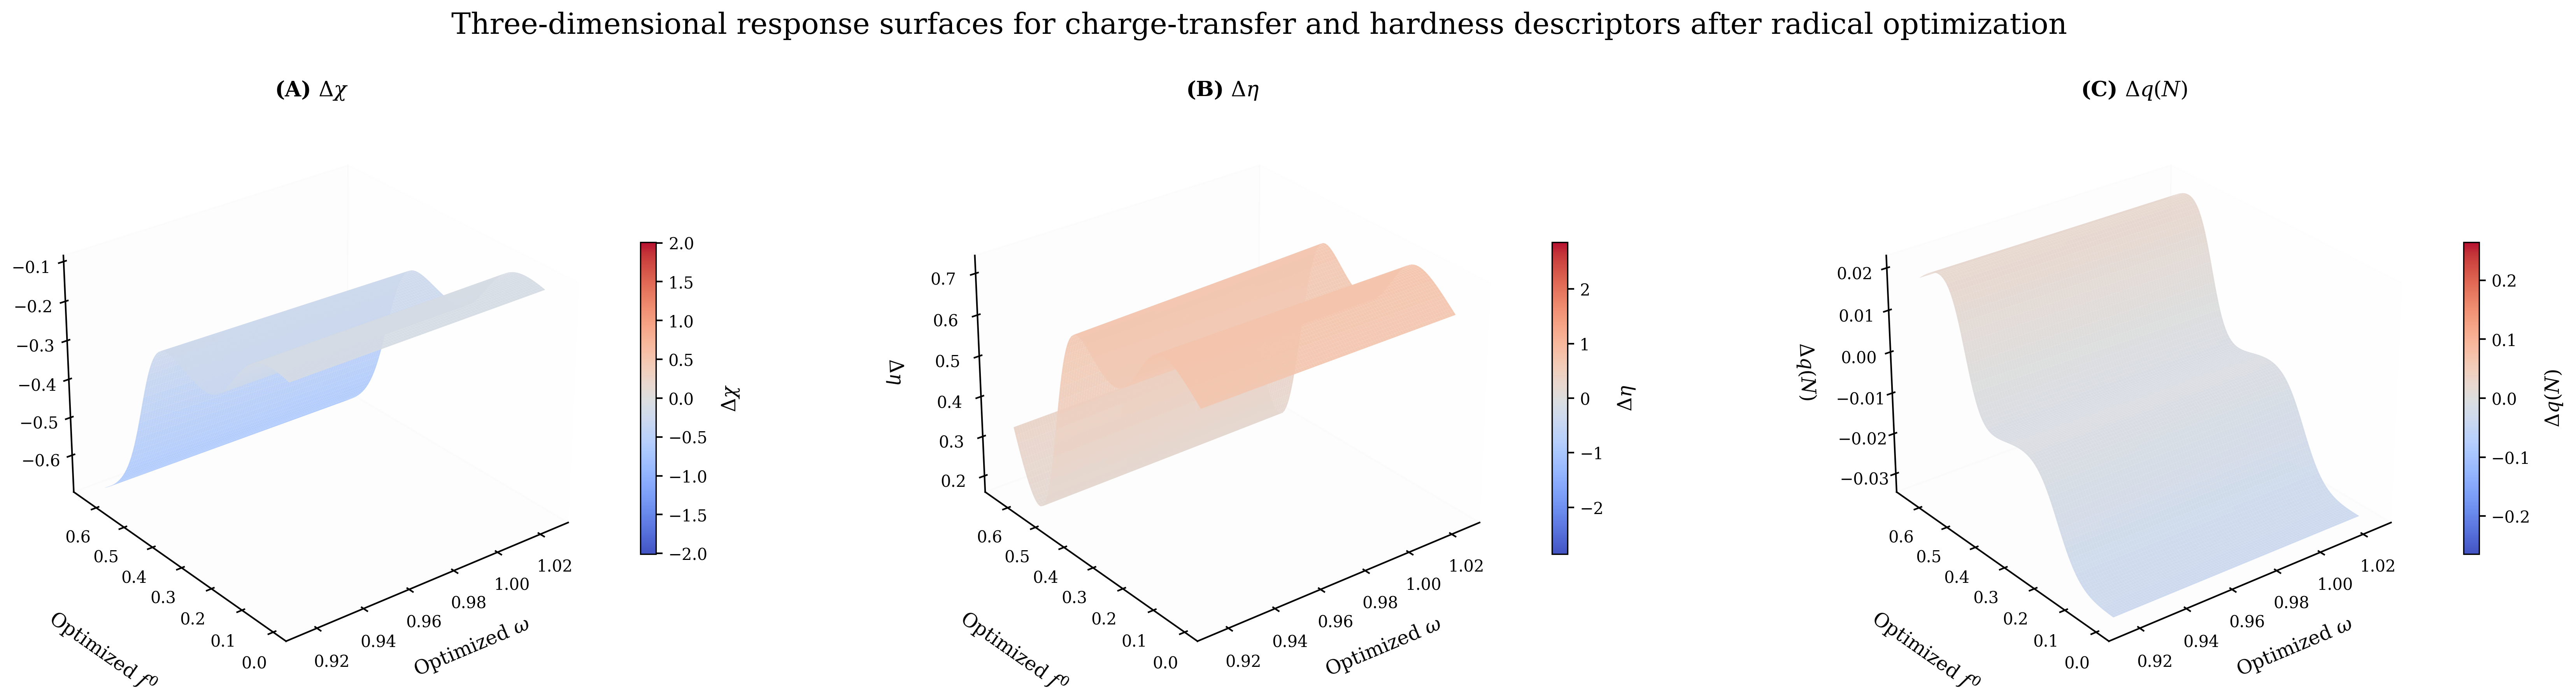

Saved: /content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/plots/descriptor_response_surfaces_3d_figure_1.png


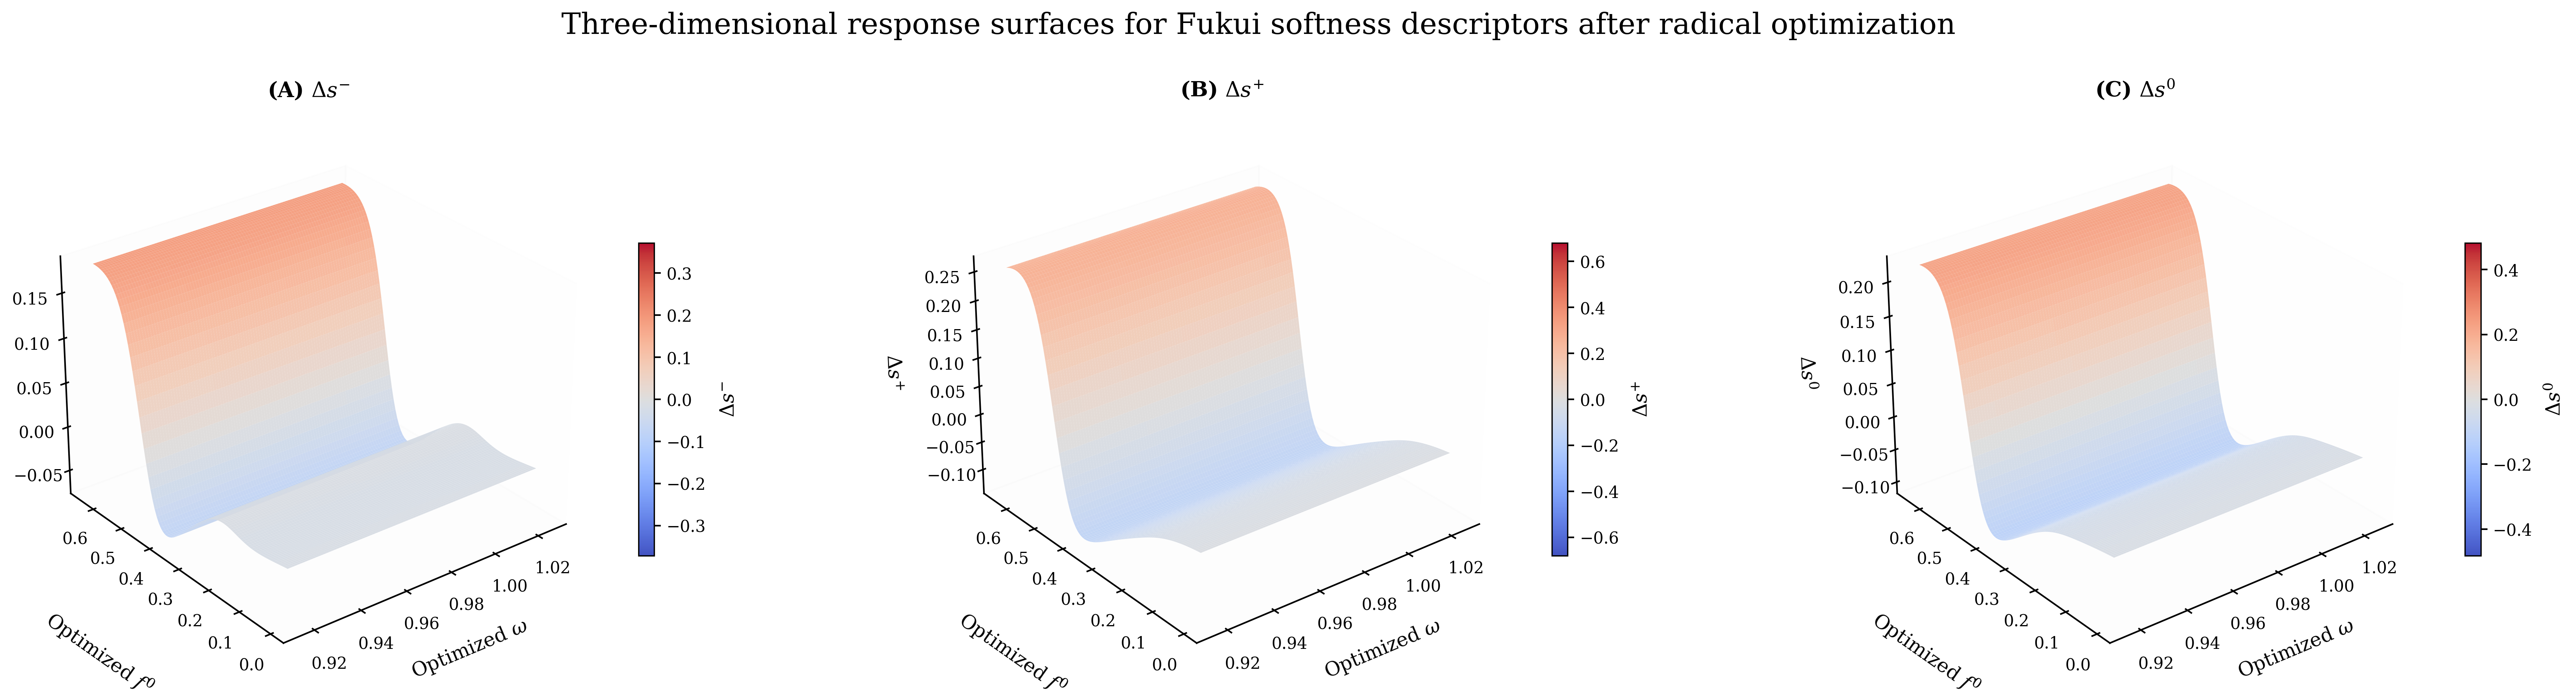

Saved: /content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/plots/descriptor_response_surfaces_3d_figure_2.png


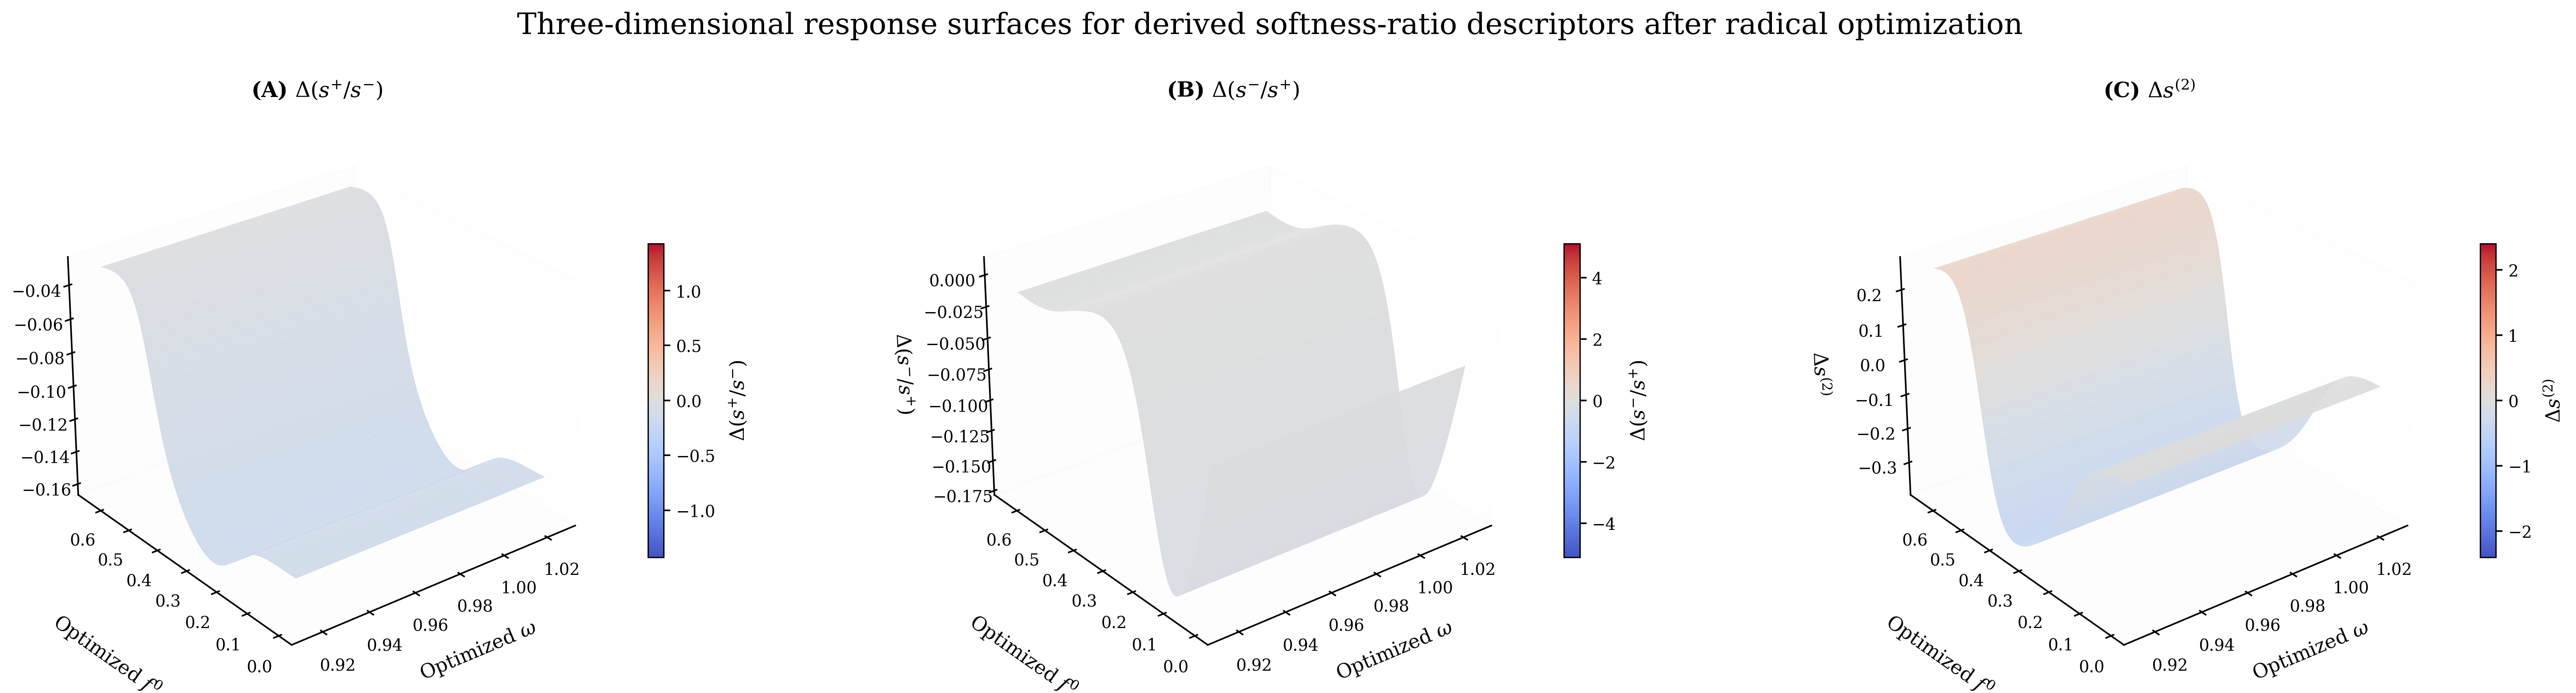

Saved: /content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/plots/descriptor_response_surfaces_3d_figure_3.png

Saved preview table: /content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/Results/pre_post_electronic_structure_preview.csv
                            Radical name  omega_pre  omega_post_rl  \
0                              indazolyl   1.491554       0.991625   
1       4trifluoromethyl_phenyl_oxidanyl   1.732520       0.982520   
2                   4-aminophenyl_methyl   0.754168       1.004059   
3   1tert-butoxy_carbonyl_pyrrolidin_2yl   0.708631       1.008522   
4    E_1_phenylethylidene_amino_oxidanyl   1.689313       0.989332   
5                   1diphenylamino_ethyl   0.903173       1.001400   
6                         benzylsulfanyl   1.229594       0.796897   
7         3-ethylbicyclo_111_pentan-1-yl   0.775320       1.209433   
8              methyldisulfanyl_sulfanyl   1.177137       0.818231   
9                             norpinanyl   0.724

In [ ]:
import os
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import RandomizedSearchCV, KFold, cross_val_predict
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
    HistGradientBoostingRegressor,
)
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.neural_network import MLPRegressor
from sklearn.multioutput import MultiOutputRegressor

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

BASE_DIR = "/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset"
RESULTS_DIR = os.path.join(BASE_DIR, "Results")
PLOTS_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

TRAIN_CSV = os.path.join(BASE_DIR, "dataset", "train_dataset.csv")
VAL_CSV = os.path.join(BASE_DIR, "dataset", "val_dataset.csv")
BEST_ACTOR = os.path.join(RESULTS_DIR, "best_actor_td3_validated_5000.pth")

STATE_COLUMNS = [
    "Electronegativity", "Hardness", "Electrophilicity", "q(N)",
    "f-", "f+", "f0", "s-", "s+", "s0", "s+/s-", "s-/s+", "s(2)"
]

INPUT_COLS = ["Electrophilicity", "f-", "f+", "f0"]
OUTPUT_COLS = ["Electronegativity", "Hardness", "q(N)", "s-", "s+", "s0", "s+/s-", "s-/s+", "s(2)"]
MAIN_PLOT_TARGETS = OUTPUT_COLS.copy()

IDX_OMEGA = 2
IDX_FM = 4
IDX_FP = 5
IDX_F0 = 6

TARGET_OMEGA = 1.0
SUCCESS_THR = 0.02
POS_CLIP = 0.05
NEG_CLIP = 0.05
MAX_STEPS = 50
FUKUI_BOUNDS = {
    "f-": (-1.0, 1.0),
    "f+": (-1.0, 1.0),
    "f0": (-1.0, 1.0),
}

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 600,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 13,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 9,
    "axes.linewidth": 1.0,
    "xtick.major.width": 1.0,
    "ytick.major.width": 1.0,
    "xtick.minor.width": 0.8,
    "ytick.minor.width": 0.8,
    "mathtext.fontset": "dejavuserif",
})

panel_titles = {
    "Electronegativity": r"$\Delta \chi$",
    "Hardness": r"$\Delta \eta$",
    "q(N)": r"$\Delta q(N)$",
    "s-": r"$\Delta s^{-}$",
    "s+": r"$\Delta s^{+}$",
    "s0": r"$\Delta s^{0}$",
    "s+/s-": r"$\Delta (s^{+}/s^{-})$",
    "s-/s+": r"$\Delta (s^{-}/s^{+})$",
    "s(2)": r"$\Delta s^{(2)}$",
}

FIGURE_GROUPS = [
    {
        "targets": ["Electronegativity", "Hardness", "q(N)"],
        "title": "Three-dimensional response surfaces for charge-transfer and hardness descriptors after radical optimization"
    },
    {
        "targets": ["s-", "s+", "s0"],
        "title": "Three-dimensional response surfaces for Fukui softness descriptors after radical optimization"
    },
    {
        "targets": ["s+/s-", "s-/s+", "s(2)"],
        "title": "Three-dimensional response surfaces for derived softness-ratio descriptors after radical optimization"
    },
]


def _safe_ratio(num, den, eps=1e-8):
    n = np.asarray(num, dtype=np.float64)
    d = np.asarray(den, dtype=np.float64)
    return n / (np.sign(d) * np.maximum(np.abs(d), eps))


def _clip_value(x, lo, hi):
    return float(np.clip(float(x), float(lo), float(hi)))


def preprocess_dataframe(df, fit_scaler=False, scaler=None):
    df = df.copy()

    for c in STATE_COLUMNS:
        if c not in df.columns:
            df[c] = np.nan

    if "s+/s-" not in df.columns:
        df["s+/s-"] = _safe_ratio(df.get("s+", 0.0), df.get("s-", 1.0))
    if "s-/s+" not in df.columns:
        df["s-/s+"] = _safe_ratio(df.get("s-", 0.0), df.get("s+", 1.0))

    for c in STATE_COLUMNS:
        df[c] = pd.to_numeric(df[c], errors="coerce")

    df[STATE_COLUMNS] = df[STATE_COLUMNS].ffill().bfill()
    df["f-"] = df["f-"].clip(*FUKUI_BOUNDS["f-"])
    df["f+"] = df["f+"].clip(*FUKUI_BOUNDS["f+"])
    df["f0"] = df["f0"].clip(*FUKUI_BOUNDS["f0"])
    df["Electrophilicity"] = df["Electrophilicity"].clip(0.0, 6.5)

    core = df[STATE_COLUMNS].copy()

    if fit_scaler:
        mu = core.mean()
        sd = core.std().replace(0.0, 1.0)
        scaler = {"mu": mu, "sd": sd}

    mu = scaler["mu"] if scaler is not None else core.mean()
    sd = scaler["sd"] if scaler is not None else core.std().replace(0.0, 1.0)

    scaled = (core - mu) / sd
    scaled["_omega_unscaled"] = core["Electrophilicity"].values.astype(np.float32)
    scaled["_omega_mu"] = mu["Electrophilicity"]
    scaled["_omega_sd"] = sd["Electrophilicity"] if sd["Electrophilicity"] != 0 else 1.0

    return core.reset_index(drop=True), scaled.reset_index(drop=True), scaler


def load_dataset():
    df_train = pd.read_csv(TRAIN_CSV)
    df_val = pd.read_csv(VAL_CSV)
    df = pd.concat([df_train, df_val], axis=0).reset_index(drop=True)

    keep_cols = [c for c in ["Radical name"] + STATE_COLUMNS if c in df.columns]
    df = df[keep_cols].copy()

    if "Radical name" in df.columns:
        df = df.drop_duplicates(subset=["Radical name"] + STATE_COLUMNS, keep="first")
    else:
        df = df.drop_duplicates(subset=STATE_COLUMNS, keep="first")

    df = df.dropna(subset=INPUT_COLS).reset_index(drop=True)
    return df


def mlp(sizes, act_last=None):
    import torch.nn as nn
    layers = []
    for i in range(len(sizes) - 2):
        layers += [nn.Linear(sizes[i], sizes[i + 1]), nn.ReLU()]
    layers.append(nn.Linear(sizes[-2], sizes[-1]))
    if act_last == "tanh":
        layers.append(nn.Tanh())
    return nn.Sequential(*layers)


class Actor(__import__("torch").nn.Module):
    def __init__(self, state_dim, hidden=128):
        super().__init__()
        self.body = mlp([state_dim, hidden, hidden, 1], act_last="tanh")

    def forward(self, s):
        return self.body(s).squeeze(1)


def run_actor_optimization(df_raw):
    import torch

    _, df_scaled, _ = preprocess_dataframe(df_raw, fit_scaler=True, scaler=None)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    actor = Actor(len(STATE_COLUMNS), hidden=128).to(device)
    actor.load_state_dict(torch.load(BEST_ACTOR, map_location=device))
    actor.eval()

    rows = []
    with torch.no_grad():
        for i in range(len(df_raw)):
            row_raw = df_raw.iloc[i].copy()
            state = df_scaled.loc[i, STATE_COLUMNS].values.astype(np.float32).copy()

            omega_mu = float(df_scaled.loc[i, "_omega_mu"])
            omega_sd = float(df_scaled.loc[i, "_omega_sd"])

            omega_pre = float(row_raw["Electrophilicity"])
            omega_final = omega_pre
            n_steps = 0

            for step in range(MAX_STEPS):
                s_t = torch.from_numpy(state).float().unsqueeze(0).to(device)
                raw = actor(s_t).item()
                action = raw * POS_CLIP if raw >= 0 else raw * NEG_CLIP
                action = float(np.clip(action, -NEG_CLIP, POS_CLIP))

                omega_now = omega_sd * float(state[IDX_OMEGA]) + omega_mu
                omega_next = float(np.clip(omega_now + action, 0.0, 6.5))
                state[IDX_OMEGA] = (omega_next - omega_mu) / (omega_sd if omega_sd != 0 else 1.0)

                omega_final = omega_next
                n_steps = step + 1

                if abs(omega_final - TARGET_OMEGA) <= SUCCESS_THR:
                    break
                if omega_final >= 5.0:
                    break

            row_raw["omega_pre"] = omega_pre
            row_raw["omega_post_rl"] = omega_final
            row_raw["omega_delta_rl"] = omega_final - omega_pre
            row_raw["actor_steps"] = n_steps
            rows.append(row_raw)

    return pd.DataFrame(rows).reset_index(drop=True)


def build_reference_candidates(df):
    cand = df[["Electrophilicity", "f-", "f+", "f0"]].dropna().copy()
    cand = cand.drop_duplicates().reset_index(drop=True)
    cand = cand.rename(columns={
        "Electrophilicity": "cand_omega",
        "f-": "cand_f-",
        "f+": "cand_f+",
        "f0": "cand_f0",
    })
    return cand


def optimize_w_and_fukui(prepost_df, candidate_df):
    out_rows = []

    cand = candidate_df.copy()
    c_omega = cand["cand_omega"].values.astype(float)
    c_fm = cand["cand_f-"].values.astype(float)
    c_fp = cand["cand_f+"].values.astype(float)
    c_f0 = cand["cand_f0"].values.astype(float)

    for _, row in prepost_df.iterrows():
        omega_seed = float(row["omega_post_rl"])
        omega_pre = float(row["Electrophilicity"])
        fm_pre = float(row["f-"])
        fp_pre = float(row["f+"])
        f0_pre = float(row["f0"])

        score = (
            3.0 * np.abs(c_omega - TARGET_OMEGA)
            + 1.25 * np.abs(c_omega - omega_seed)
            + 0.80 * np.abs(c_fm - fm_pre)
            + 0.80 * np.abs(c_fp - fp_pre)
            + 0.80 * np.abs(c_f0 - f0_pre)
            + 0.20 * np.abs(c_fm + c_fp - 2.0 * c_f0)
        )

        best_idx = int(np.argmin(score))

        row = row.copy()
        row["omega_post"] = float(c_omega[best_idx])
        row["f-_post"] = _clip_value(c_fm[best_idx], *FUKUI_BOUNDS["f-"])
        row["f+_post"] = _clip_value(c_fp[best_idx], *FUKUI_BOUNDS["f+"])
        row["f0_post"] = _clip_value(c_f0[best_idx], *FUKUI_BOUNDS["f0"])

        row["omega_delta"] = row["omega_post"] - omega_pre
        row["f-_delta"] = row["f-_post"] - fm_pre
        row["f+_delta"] = row["f+_post"] - fp_pre
        row["f0_delta"] = row["f0_post"] - f0_pre
        row["omega_hit_target"] = abs(row["omega_post"] - TARGET_OMEGA) <= SUCCESS_THR
        out_rows.append(row)

    out = pd.DataFrame(out_rows).reset_index(drop=True)
    save_path = os.path.join(RESULTS_DIR, "optimized_w_fukui_results_self_contained.csv")
    out.to_csv(save_path, index=False)
    print(f"Saved optimized ω/Fukui table: {save_path}")
    return out


def get_candidate_models():
    return {
        "RF": (
            RandomForestRegressor(random_state=SEED, n_jobs=-1),
            {
                "n_estimators": [200, 400, 800],
                "max_depth": [None, 5, 10, 20],
                "min_samples_split": [2, 4, 8, 12],
                "min_samples_leaf": [1, 2, 4, 8],
                "max_features": ["sqrt", "log2", None],
            },
        ),
        "ET": (
            ExtraTreesRegressor(random_state=SEED, n_jobs=-1),
            {
                "n_estimators": [200, 400, 800],
                "max_depth": [None, 5, 10, 20],
                "min_samples_split": [2, 4, 8, 12],
                "min_samples_leaf": [1, 2, 4, 8],
                "max_features": ["sqrt", "log2", None],
            },
        ),
        "GBR": (
            MultiOutputRegressor(GradientBoostingRegressor(random_state=SEED)),
            {
                "estimator__n_estimators": [100, 200, 400],
                "estimator__learning_rate": [0.01, 0.03, 0.05, 0.1],
                "estimator__max_depth": [2, 3, 4, 5],
                "estimator__subsample": [0.6, 0.8, 1.0],
                "estimator__min_samples_leaf": [1, 2, 4, 8],
            },
        ),
        "HGBR": (
            MultiOutputRegressor(HistGradientBoostingRegressor(random_state=SEED)),
            {
                "estimator__learning_rate": [0.01, 0.03, 0.05, 0.1],
                "estimator__max_depth": [None, 3, 5, 8],
                "estimator__max_iter": [200, 400, 800],
                "estimator__min_samples_leaf": [5, 10, 20, 30],
                "estimator__l2_regularization": [0.0, 1e-4, 1e-3, 1e-2],
            },
        ),
        "KNN": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", MultiOutputRegressor(KNeighborsRegressor())),
            ]),
            {
                "model__estimator__n_neighbors": [3, 5, 7, 9, 11, 15],
                "model__estimator__weights": ["uniform", "distance"],
                "model__estimator__p": [1, 2],
            },
        ),
        "SVR": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", MultiOutputRegressor(SVR())),
            ]),
            {
                "model__estimator__kernel": ["rbf", "poly"],
                "model__estimator__C": [0.1, 1, 3, 10, 30, 100],
                "model__estimator__epsilon": [0.001, 0.01, 0.05, 0.1, 0.2],
                "model__estimator__gamma": ["scale", "auto"],
                "model__estimator__degree": [2, 3],
            },
        ),
        "MLP": (
            Pipeline([
                ("scaler", StandardScaler()),
                ("model", MLPRegressor(random_state=SEED, max_iter=5000, early_stopping=True)),
            ]),
            {
                "model__hidden_layer_sizes": [(64,), (128,), (64, 64), (128, 64), (128, 128), (256, 128)],
                "model__activation": ["relu", "tanh"],
                "model__alpha": [1e-6, 1e-5, 1e-4, 1e-3, 1e-2],
                "model__learning_rate_init": [1e-4, 3e-4, 1e-3, 3e-3],
            },
        ),
    }


def compute_multioutput_metrics(y_true, y_pred, target_names):
    rows = []
    for j, target in enumerate(target_names):
        yt = np.asarray(y_true)[:, j]
        yp = np.asarray(y_pred)[:, j]

        mae = mean_absolute_error(yt, yp)
        rmse = np.sqrt(mean_squared_error(yt, yp))
        r2 = r2_score(yt, yp)

        target_std = np.std(yt, ddof=1)
        if target_std == 0:
            target_std = 1.0

        nmae = mae / target_std
        nrmse = rmse / target_std

        rows.append({
            "Target": target,
            "R2": r2,
            "MAE": mae,
            "RMSE": rmse,
            "NMAE": nmae,
            "NRMSE": nrmse,
        })

    metrics_df = pd.DataFrame(rows)

    summary = {
        "Mean_R2": metrics_df["R2"].mean(),
        "Mean_MAE": metrics_df["MAE"].mean(),
        "Mean_RMSE": metrics_df["RMSE"].mean(),
        "Mean_NMAE": metrics_df["NMAE"].mean(),
        "Mean_NRMSE": metrics_df["NRMSE"].mean(),
        "Overall_Error_Score": 0.5 * (metrics_df["NMAE"].mean() + metrics_df["NRMSE"].mean()),
    }
    return metrics_df, summary


def fit_best_overall_model(df, n_iter=20):
    X = df[INPUT_COLS].copy()
    Y = df[OUTPUT_COLS].copy()
    cv = KFold(n_splits=5, shuffle=True, random_state=SEED)
    candidates = get_candidate_models()

    selection_rows = []
    model_store = {}

    print("\n===== Selecting one overall best model based on lowest overall error =====")
    for model_name, (estimator, param_grid) in candidates.items():
        search = RandomizedSearchCV(
            estimator=estimator,
            param_distributions=param_grid,
            n_iter=n_iter,
            scoring="neg_root_mean_squared_error",
            cv=cv,
            random_state=SEED,
            n_jobs=-1,
            refit=True,
        )
        search.fit(X, Y)

        best_estimator = search.best_estimator_
        y_cv = cross_val_predict(best_estimator, X, Y, cv=cv, n_jobs=-1)
        per_target_metrics, summary = compute_multioutput_metrics(Y.values, y_cv, OUTPUT_COLS)

        row = {
            "Model": model_name,
            "Best params": str(search.best_params_),
            "Mean_R2": summary["Mean_R2"],
            "Mean_MAE": summary["Mean_MAE"],
            "Mean_RMSE": summary["Mean_RMSE"],
            "Mean_NMAE": summary["Mean_NMAE"],
            "Mean_NRMSE": summary["Mean_NRMSE"],
            "Overall_Error_Score": summary["Overall_Error_Score"],
        }
        selection_rows.append(row)

        model_store[model_name] = {
            "best_estimator": best_estimator,
            "best_params": search.best_params_,
            "per_target_metrics": per_target_metrics,
            "summary": summary,
        }

        print(
            f"{model_name:5s} | Overall score={summary['Overall_Error_Score']:.4f} | "
            f"Mean NMAE={summary['Mean_NMAE']:.4f} | Mean NRMSE={summary['Mean_NRMSE']:.4f} | "
            f"Mean R2={summary['Mean_R2']:.4f}"
        )

    selection_df = pd.DataFrame(selection_rows).sort_values(
        by=["Overall_Error_Score", "Mean_NRMSE", "Mean_NMAE"],
        ascending=[True, True, True]
    ).reset_index(drop=True)

    best_model_name = selection_df.loc[0, "Model"]
    best_model = model_store[best_model_name]["best_estimator"]
    best_params = model_store[best_model_name]["best_params"]
    best_per_target_metrics = model_store[best_model_name]["per_target_metrics"].copy()

    best_model.fit(X, Y)

    selection_path = os.path.join(RESULTS_DIR, "overall_model_selection_summary.csv")
    per_target_path = os.path.join(RESULTS_DIR, "overall_best_model_per_target_metrics.csv")
    selection_df.to_csv(selection_path, index=False)
    best_per_target_metrics.to_csv(per_target_path, index=False)

    print(f"\nSELECTED OVERALL MODEL -> {best_model_name}")
    print(f"Best params -> {best_params}")
    print(f"Saved overall selection summary: {selection_path}")
    print(f"Saved per-target metrics for selected overall model: {per_target_path}")

    return best_model, best_model_name, best_params, selection_df, best_per_target_metrics


def apply_overall_model(prepost_df, overall_model):
    out = prepost_df.copy()

    X_pre = out[INPUT_COLS].copy()
    X_post = pd.DataFrame({
        "Electrophilicity": out["omega_post"].values,
        "f-": out["f-_post"].values,
        "f+": out["f+_post"].values,
        "f0": out["f0_post"].values,
    })

    pred_pre = overall_model.predict(X_pre)
    pred_post = overall_model.predict(X_post)

    for idx, target in enumerate(OUTPUT_COLS):
        out[f"{target}_pred_pre"] = pred_pre[:, idx]
        out[f"{target}_pred_post"] = pred_post[:, idx]
        out[f"{target}_change"] = out[f"{target}_pred_post"] - out[f"{target}_pred_pre"]

    out_path = os.path.join(RESULTS_DIR, "pre_post_electronic_structure_overall_model.csv")
    out.to_csv(out_path, index=False)
    print(f"Saved descriptor table: {out_path}")
    return out


def make_descriptor_change_summary(df_out):
    rows = []
    for target in OUTPUT_COLS:
        rows.append({
            "Descriptor": target,
            "Mean abs change": np.mean(np.abs(df_out[f"{target}_change"])),
            "Median abs change": np.median(np.abs(df_out[f"{target}_change"])),
            "Max abs change": np.max(np.abs(df_out[f"{target}_change"])),
        })
    summary_df = pd.DataFrame(rows).sort_values("Mean abs change", ascending=False)
    out_path = os.path.join(RESULTS_DIR, "descriptor_change_summary.csv")
    summary_df.to_csv(out_path, index=False)
    print(f"Saved change summary: {out_path}")
    return summary_df


def local_weighted_grid(xdata, ydata, zdata, XX, YY, bandwidth_x=0.22, bandwidth_y=0.08):
    Z = np.zeros_like(XX, dtype=float)
    W = np.zeros_like(XX, dtype=float)

    for xi, yi, zi in zip(xdata, ydata, zdata):
        wx = np.exp(-0.5 * ((XX - xi) / bandwidth_x) ** 2)
        wy = np.exp(-0.5 * ((YY - yi) / bandwidth_y) ** 2)
        w = wx * wy
        Z += w * zi
        W += w

    Z = np.divide(Z, W, out=np.full_like(Z, np.nan), where=W > 1e-12)
    return Z


def plot_3d_surfaces_publication(df_out, figure_groups=FIGURE_GROUPS, x_col="omega_post", y_col="f0_post"):
    omega_min = max(0.0, float(df_out[x_col].quantile(0.01)))
    omega_max = min(6.5, float(df_out[x_col].quantile(0.99)))
    f0_min = float(df_out[y_col].quantile(0.01))
    f0_max = float(df_out[y_col].quantile(0.99))

    omega_grid = np.linspace(omega_min, omega_max, 100)
    f0_grid = np.linspace(f0_min, f0_max, 100)
    XX, YY = np.meshgrid(omega_grid, f0_grid)

    for fig_idx, group in enumerate(figure_groups, start=1):
        targets = group["targets"]
        overall_title = group["title"]

        fig = plt.figure(figsize=(22.0, 6.5), constrained_layout=False)

        for i, target in enumerate(targets, start=1):
            z = df_out[f"{target}_change"].values
            Z = local_weighted_grid(
                df_out[x_col].values,
                df_out[y_col].values,
                z,
                XX,
                YY,
                bandwidth_x=0.20,
                bandwidth_y=0.08
            )

            vmax = np.nanquantile(np.abs(z), 0.98)
            vmin = -vmax

            ax = fig.add_subplot(1, 3, i, projection="3d")
            surf = ax.plot_surface(
                XX, YY, Z,
                cmap="coolwarm",
                linewidth=0,
                antialiased=True,
                alpha=0.96,
                vmin=vmin,
                vmax=vmax,
                rcount=100,
                ccount=100
            )

            ax.set_title(f"({chr(64+i)}) {panel_titles[target]}", pad=14, fontweight="semibold")
            ax.set_xlabel(r"Optimized $\omega$", labelpad=10)
            ax.set_ylabel(r"Optimized $f^{0}$", labelpad=24)
            ax.set_zlabel(panel_titles[target], labelpad=10)
            ax.view_init(elev=28, azim=-128)

            ax.xaxis.pane.set_alpha(0.06)
            ax.yaxis.pane.set_alpha(0.06)
            ax.zaxis.pane.set_alpha(0.06)
            ax.grid(False)

            cbar = fig.colorbar(surf, ax=ax, fraction=0.025, pad=0.080, shrink=0.82)
            cbar.set_label(panel_titles[target], rotation=90, labelpad=8)
            cbar.outline.set_linewidth(0.8)

        fig.suptitle(overall_title, fontsize=18, y=0.98)
        fig.subplots_adjust(left=0.022, right=0.975, bottom=0.06, top=0.88, wspace=0.46)

        out_path = os.path.join(PLOTS_DIR, f"descriptor_response_surfaces_3d_figure_{fig_idx}.png")
        plt.savefig(out_path, bbox_inches="tight")
        plt.show()
        print(f"Saved: {out_path}")


def main():
    df_all = load_dataset()
    print("Dataset shape after deduplication:", df_all.shape)

    overall_model, overall_model_name, overall_best_params, selection_df, per_target_df = fit_best_overall_model(df_all, n_iter=20)

    print("\nOverall model ranking:")
    print(selection_df)

    print("\nPer-target metrics using the selected overall model:")
    print(per_target_df)

    rl_df = run_actor_optimization(df_all)
    candidate_df = build_reference_candidates(df_all)
    prepost_df = optimize_w_and_fukui(rl_df, candidate_df)

    df_out = apply_overall_model(prepost_df, overall_model)

    change_summary = make_descriptor_change_summary(df_out)
    print("\nDescriptor change summary:")
    print(change_summary)

    plot_3d_surfaces_publication(df_out, figure_groups=FIGURE_GROUPS, x_col="omega_post", y_col="f0_post")

    important_cols = [
        "Radical name",
        "omega_pre", "omega_post_rl", "omega_post", "omega_delta",
        "f-", "f-_post", "f-_delta",
        "f+", "f+_post", "f+_delta",
        "f0", "f0_post", "f0_delta",
        "omega_hit_target",
    ]
    for t in MAIN_PLOT_TARGETS:
        important_cols += [f"{t}_pred_pre", f"{t}_pred_post", f"{t}_change"]

    important_cols = [c for c in important_cols if c in df_out.columns]
    preview_path = os.path.join(RESULTS_DIR, "pre_post_electronic_structure_preview.csv")
    df_out[important_cols].to_csv(preview_path, index=False)
    print(f"\nSaved preview table: {preview_path}")
    print(df_out[important_cols].head(20))


if __name__ == "__main__":
    main()

##**Mayr's Scale**

In [ ]:
!pip -q install requests beautifulsoup4 lxml openpyxl pandas

In [ ]:
import os
import re
import requests
import pandas as pd
from bs4 import BeautifulSoup
from urllib.parse import urljoin, urlparse, parse_qsl, urlencode, urlunparse

BASE_DIR = "/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset"
RESULTS_DIR = os.path.join(BASE_DIR, "Results")
os.makedirs(RESULTS_DIR, exist_ok=True)

BASE = "https://www.cup.lmu.de/oc/mayr/reaktionsdatenbank2/"
ROOT = BASE

OUT_CSV = os.path.join(RESULTS_DIR, "mayr_electrophiles_all_classes.csv")

session = requests.Session()
session.headers.update({"User-Agent": "Mozilla/5.0"})

def get_soup(url):
    r = session.get(url, timeout=30)
    r.raise_for_status()
    return BeautifulSoup(r.text, "html.parser")

def add_num0(url):
    parts = list(urlparse(url))
    q = dict(parse_qsl(parts[4]))
    q["num"] = "0"
    parts[4] = urlencode(q)
    return urlunparse(parts)

def extract_e_rows_from_page(url, subclass_name):
    soup = get_soup(add_num0(url))
    text = soup.get_text("\n", strip=True)
    lines = [x.strip() for x in text.split("\n") if x.strip()]

    rows = []
    for i, line in enumerate(lines):
        m = re.match(r"E\s*Param\.\s*:\s*([-+]?\d+(?:\.\d+)?)", line)
        if not m:
            continue

        e_val = float(m.group(1))
        name = None
        doi = None

        for j in range(i - 1, max(-1, i - 10), -1):
            cand = lines[j]

            if doi is None and re.match(r"^10\.\d{4,9}/", cand):
                doi = cand
                continue

            bad = (
                cand.startswith("Image")
                or cand.startswith("E Param.")
                or cand.startswith("Mayr")
                or cand.startswith("Advanced Search")
                or cand.startswith("Electrophiles")
                or cand.startswith("Nucleophiles")
                or cand.startswith("Found ")
                or cand.startswith("Results per page")
                or cand in {"Name", "Solvent", "Reactivity Parameters", "Classification", "Reference"}
                or re.match(r"^\d+\s*\|", cand)
                or re.match(r"^10\.", cand)
            )
            if not bad:
                name = cand
                break

        rows.append({
            "compound": name,
            "E_param": e_val,
            "mayr_subclass": subclass_name,
            "source_url": add_num0(url),
            "doi": doi
        })

    return pd.DataFrame(rows).drop_duplicates()

root = get_soup(ROOT)
subclass_links = []

for a in root.find_all("a", href=True):
    href = urljoin(BASE, a["href"])
    text = a.get_text(" ", strip=True)

    if "/fe/showclass/" in href:
        if text and text != "Electrophiles (377)":
            subclass_links.append((text, href))

seen = set()
clean_links = []
for text, href in subclass_links:
    key = (text, href)
    if key not in seen:
        seen.add(key)
        clean_links.append((text, href))

all_frames = []
for text, href in clean_links:
    try:
        df_part = extract_e_rows_from_page(href, text)
        if len(df_part) > 0:
            print(f"{text}: {len(df_part)} rows")
            all_frames.append(df_part)
    except Exception as e:
        print(f"Failed on {text}: {e}")

df_all = pd.concat(all_frames, ignore_index=True).drop_duplicates()

print("Total extracted rows:", len(df_all))
print(df_all.head(20))

df_all.to_csv(OUT_CSV, index=False)
print(f"Saved -> {OUT_CSV}")

C-Electrophiles (352): 339 rows
Carbocations (134): 132 rows
Diarylcarbenium Ions (33): 33 rows
Triarylcarbenium Ions (25): 25 rows
Indolyl-stabilized carbocations (12): 12 rows
Other conjugated carbocations (23): 23 rows
N-substituted carbocations (iminium ions) (31): 29 rows
O-substituted carbocations (carboxonium ions) (5): 5 rows
S-substituted carbocations (3): 3 rows
Keteneiminium Ions (2): 2 rows
Cationic Metal-π-Complexes (20): 20 rows
Fe-stabilized carbocations (9): 9 rows
Co-stabilized carbocations (5): 5 rows
Other metal-stabilized carbocations (6): 6 rows
Acceptor-Substituted Ethylenes (137): 136 rows
Acyl azolium ions (6): 6 rows
Baylis-Hillman adducts (7): 7 rows
Benzylidenemalonates (9): 9 rows
Bissulfonyl ethylenes (7): 7 rows
1,2-Diaza-1,3-dienes (6): 6 rows
Quinone Methides (38): 38 rows
trans-β -Nitrostyrenes (6): 6 rows
Other Michael acceptors (58): 57 rows
Arenes (electron-deficient) (16): 16 rows
Aldehydes (11): 3 rows
Heteroallenes (X=C=Y)  (6): 6 rows
Imines (5):

In [ ]:
import os
import re
import pandas as pd
import numpy as np

# =========================================================
# PATHS
# =========================================================
BASE_DIR = "/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset"
RESULTS_DIR = os.path.join(BASE_DIR, "Results")
os.makedirs(RESULTS_DIR, exist_ok=True)

INFILE = os.path.join(RESULTS_DIR, "mayr_electrophiles_all_classes.csv")
OUTFILE = os.path.join(RESULTS_DIR, "mayr_electrophiles_classified_to_radical_motifs.csv")

# =========================================================
# LOAD
# =========================================================
df = pd.read_csv(INFILE)

# -------------------------------
# 1. CLEAN
# -------------------------------
df["compound"] = df["compound"].astype(str).str.strip()
df["mayr_subclass"] = df["mayr_subclass"].astype(str).str.strip()

df["mayr_subclass_clean"] = (
    df["mayr_subclass"]
    .str.replace(r"\s*\(\d+\)\s*$", "", regex=True)
    .str.strip()
)

# -------------------------------
# 2. DEDUPLICATE
# -------------------------------
df["subclass_len"] = df["mayr_subclass_clean"].str.len()

df = df.sort_values(
    by=["compound", "subclass_len"],
    ascending=[True, False]
).copy()

df_unique = df.drop_duplicates(
    subset=["compound", "E_param"],
    keep="first"
).reset_index(drop=True)

print("Original rows:", len(df))
print("Unique rows after dedup:", len(df_unique))

# -------------------------------
# 3. RULE-BASED CLASSIFICATION
# -------------------------------
def classify_mayr_to_radical_motif(compound, subclass):
    c = str(compound).lower()
    s = str(subclass).lower()

    if "quinone methide" in s:
        return "Aromatic carbon radical"

    if "diarylcarbenium" in s or "triarylcarbenium" in s:
        return "Aromatic carbon radical"

    if "benzhydrylium" in s:
        return "Aromatic carbon radical"

    if "iminium" in s:
        return "Nitrogen radical"

    if "azo" in s or "diazo" in s or "nitroso" in s or "nitrosonium" in s:
        return "Nitrogen radical"

    if "aldehyde" in s or "ketone" in s or "acyl" in s or "carbonyl" in s:
        return "Oxygen radical"

    if "sulfenyl" in s or "sulfonyl" in s or "sulfur" in s or "sulphur" in s:
        return "Sulfur radical"

    if "phosph" in s:
        return "Phosphoryl radical"

    if "silyl" in s or "silicon" in s:
        return "Silyl radical"

    if "boryl" in s or "boron" in s:
        return "Boryl radical"

    if "halonium" in s or "halogen" in s:
        return "Halogen substituted carbon radical"

    if "acceptor-substituted ethylene" in s or "michael acceptor" in s:
        return "Aliphatic carbon radical"

    if "qm" in c:
        return "Aromatic carbon radical"

    if "ch+" in c:
        return "Aromatic carbon radical"

    if any(x in c for x in ["iminium", "nh+", "n+", "pyr", "indol", "quinol", "isoquinol", "aza"]):
        return "Nitrogen radical"

    if any(x in c for x in ["oxo", "acyl", "cho", "co2", "coor", "cor", "oh", "or"]):
        return "Oxygen radical"

    if any(x in c for x in ["sulf", "sulph", "so2", "sr", "s+"]):
        return "Sulfur radical"

    if any(x in c for x in ["phosph", "po", "p="]):
        return "Phosphoryl radical"

    if any(x in c for x in ["si", "silyl", "tms", "tes", "tbs"]):
        return "Silyl radical"

    if any(x in c for x in ["bor", "bpin", "b(cat)", "bf3", "b("]):
        return "Boryl radical"

    if any(x in c for x in ["f", "cl", "br", "i", "cf3", "ccl3", "pfp", "pfa", "mfa"]):
        if "ch+" not in c:
            return "Halogen substituted carbon radical"

    if any(x in c for x in ["ph", "ani", "tol", "dma", "fur", "pyr", "jul", "pcp"]):
        return "Aromatic carbon radical"

    return "Aliphatic carbon radical"

df_unique["mapped_motif"] = df_unique.apply(
    lambda row: classify_mayr_to_radical_motif(
        row["compound"],
        row["mayr_subclass_clean"]
    ),
    axis=1
)

# -------------------------------
# 4. REVIEW OUTPUT
# -------------------------------
print("\nMapped motif counts:\n")
print(df_unique["mapped_motif"].value_counts(dropna=False))

print("\nExamples by motif:\n")
for motif in sorted(df_unique["mapped_motif"].dropna().unique()):
    print(f"\n=== {motif} ===")
    print(
        df_unique.loc[
            df_unique["mapped_motif"] == motif,
            ["compound", "E_param", "mayr_subclass_clean"]
        ].head(10)
    )

# -------------------------------
# 5. SAVE
# -------------------------------
df_unique.to_csv(OUTFILE, index=False)
print(f"\nSaved -> {OUTFILE}")

Original rows: 1001
Unique rows after dedup: 364

Mapped motif counts:

mapped_motif
Aliphatic carbon radical              161
Aromatic carbon radical                62
Nitrogen radical                       58
Halogen substituted carbon radical     49
Oxygen radical                         34
Name: count, dtype: int64

Examples by motif:


=== Aliphatic carbon radical ===
                                             compound  E_param  \
28  (E)-10-(4-methoxybenzylidene)phenanthren-9(10H...   -15.93   
29  (E)-2-(4-methoxybenzylidene)acenaphthylen-1(2H...   -18.72   
32  (E)-6-((1-methyl-1H-indol-2-yl)methylene)benzo...   -15.55   
33  (E)-6-((1-methyl-1H-pyrrol-2-yl)methylene)benz...   -17.03   
34  (E)-6-((E)-3-phenylallylidene)benzo[d][1,3]dio...   -16.00   
35  (E)-6-(3-fluorobenzylidene)benzo[d][1,3]dioxol...   -14.00   
36  (E)-6-(4-(dimethylamino)benzylidene)benzo[d][1...   -16.07   
37  (E)-6-(4-(trifluoromethyl)benzylidene)benzo[d]...   -13.54   
38  (E)-6-(4-chlorobenzylidene

In [ ]:
import os
import re
import pandas as pd
import numpy as np

# =========================================================
# PATHS
# =========================================================
BASE_DIR = "/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset"
RESULTS_DIR = os.path.join(BASE_DIR, "Results")
os.makedirs(RESULTS_DIR, exist_ok=True)

INFILE = os.path.join(RESULTS_DIR, "mayr_electrophiles_all_classes.csv")
OUTFILE = os.path.join(RESULTS_DIR, "mayr_electrophiles_classified_to_radical_motifs_v2.csv")

# =========================================================
# LOAD
# =========================================================
df = pd.read_csv(INFILE)

df["compound"] = df["compound"].astype(str).str.strip()
df["mayr_subclass"] = df["mayr_subclass"].astype(str).str.strip()

df["mayr_subclass_clean"] = (
    df["mayr_subclass"]
    .str.replace(r"\s*\(\d+\)\s*$", "", regex=True)
    .str.strip()
)

# prefer more specific subclass names over broad parent pages
df["subclass_len"] = df["mayr_subclass_clean"].str.len()
df = df.sort_values(["compound", "subclass_len"], ascending=[True, False]).copy()

df_unique = df.drop_duplicates(subset=["compound", "E_param"], keep="first").reset_index(drop=True)

def has_any(text, patterns):
    t = str(text).lower()
    return any(p in t for p in patterns)

def classify_mayr_motif(compound, subclass):
    c = str(compound).lower()
    s = str(subclass).lower()

    # -----------------------------
    # 1) subclass-dominant rules
    # -----------------------------
    if has_any(s, ["cationic metal", "metal-stabilized", "co2(co)", "cr(co)", "metal-π", "metal-pi"]):
        return "Inorganic radical"

    if has_any(s, ["s-electrophiles", "thiolating", "sulfenyl", "sulfur", "sulphur", "sulfonyl", "sulfanyl"]):
        return "Sulfur substituted carbon"

    if has_any(s, ["phosph", "phosphonium", "phosphoryl"]):
        return "Phosphoryl radical"

    if has_any(s, ["silyl", "silicon"]):
        return "Silicon substituted carbon"

    if has_any(s, ["boryl", "boron", "borane", "boronium"]):
        return "Boryl radical"

    if has_any(s, ["n-substituted carbocations", "iminium"]):
        return "Nitrogen substituted carbon"

    if has_any(s, ["indolyl-stabilized carbocations", "quinolyl", "isoquinolyl", "pyridinium", "heteroaryl"]):
        return "Heteroaryl radical"

    if has_any(s, ["diarylcarbenium", "triarylcarbenium", "benzhydrylium", "tritylium"]):
        return "Aromatic carbon radical"

    if has_any(s, ["arenes (electron-deficient)", "arenes", "aryl-substituted", "other conjugated carbocations"]):
        return "Aromatic carbon radical"

    if has_any(s, ["quinone methide"]):
        return "Oxygen substituted carbon"

    if has_any(s, ["acceptor-substituted ethylenes", "michael acceptor", "acceptor substituted ethylenes"]):
        if has_any(c, ["indol", "pyrrol", "quinol", "isoquinol", "imid", "aza"]):
            return "Heteroaryl radical"
        if has_any(c, ["iminium", "amino", "dimethylamino", "julolidin", "anilino"]):
            return "Nitrogen substituted carbon"
        if has_any(c, ["oxo", "one", "dione", "aldehyde", "ketone", "ester", "quinone", "dioxol", "methoxy", "alkoxy"]):
            return "Oxygen substituted carbon"
        if has_any(c, ["phenyl", "benzylidene", "aryl", "trityl", "anisyl", "tolyl"]):
            return "Aromatic carbon radical"
        return "Aliphatic carbon radical"

    # -----------------------------
    # 2) compound-name rules
    # -----------------------------
    if has_any(c, ["tritylium", "benzhydrylium", "carbenium", "allylium", "ethylium", "ylium"]):
        if has_any(c, ["indol", "quinol", "isoquinol", "pyrid", "fur", "thioph", "pyrrol"]):
            return "Heteroaryl radical"
        if has_any(c, ["ph", "phenyl", "aryl", "tol", "ani", "anis", "trityl", "benz"]):
            return "Aromatic carbon radical"
        return "Aliphatic carbon radical"

    if "qm" in c or has_any(c, ["quinone methide", "quinone"]):
        return "Oxygen substituted carbon"

    if has_any(c, ["iminium", "n+=ch", "pyridinium", "quinolinium", "isoquinolinium"]):
        return "Nitrogen substituted carbon"

    if has_any(c, ["indol", "pyrrol", "fur", "thioph", "benzofur", "benzothioph", "imid", "aza"]):
        return "Heteroaryl radical"

    if has_any(c, ["sulfen", "sulf", "sulph", "so2", "s+"]):
        return "Sulfur substituted carbon"

    if has_any(c, ["phosph", "po(", "p(=o)", "phosphonium"]):
        return "Phosphoryl radical"

    if has_any(c, ["silyl", "trimethylsilyl", "tms", "tes", "tbs", "si"]):
        return "Silicon substituted carbon"

    if has_any(c, ["bor", "bcl3", "bf3", "bpin", "borane", "boron"]):
        return "Boryl radical"

    if has_any(c, ["aldehyde", "ketone", "ester", "acyl", "carbonyl", "quinone", "dione", "dioxol", "methoxy", "alkoxy", "oxy"]):
        return "Oxygen substituted carbon"

    if has_any(c, ["cf3", "ccl3", "perfluoro", "fluoro", "chloro", "bromo", "iodo", "pfp"]):
        if has_any(c, ["phenyl", "aryl", "benz", "tritylium", "carbenium", "allylium"]):
            return "Halogen substituted carbon radical"
        return "Halogen substituted carbon radical"

    if has_any(c, ["phenyl", "aryl", "benz", "tol", "ani", "anis", "trityl"]):
        return "Aromatic carbon radical"

    return "Aliphatic carbon radical"

df_unique["mapped_motif_v2"] = df_unique.apply(
    lambda row: classify_mayr_motif(row["compound"], row["mayr_subclass_clean"]),
    axis=1
)

print("Original rows:", len(df))
print("Unique rows after dedup:", len(df_unique))
print("\nMapped motif counts:\n")
print(df_unique["mapped_motif_v2"].value_counts())

print("\nExamples by motif:\n")
for motif in sorted(df_unique["mapped_motif_v2"].dropna().unique()):
    print(f"\n=== {motif} ===")
    print(
        df_unique.loc[
            df_unique["mapped_motif_v2"] == motif,
            ["compound", "E_param", "mayr_subclass_clean"]
        ].head(12)
    )

df_unique.to_csv(OUTFILE, index=False)
print(f"\nSaved -> {OUTFILE}")

Original rows: 1001
Unique rows after dedup: 364

Mapped motif counts:

mapped_motif_v2
Aliphatic carbon radical       122
Aromatic carbon radical        118
Nitrogen substituted carbon     42
Oxygen substituted carbon       35
Inorganic radical               20
Heteroaryl radical              15
Sulfur substituted carbon        9
Boryl radical                    3
Name: count, dtype: int64

Examples by motif:


=== Aliphatic carbon radical ===
                                    compound  E_param  \
79                      1,3-dithianylium ion    -2.14   
119   4-bromo-<i>trans-beta</i>-nitrostyrene   -13.37   
122   4-cyano-<i>trans-beta</i>-nitrostyrene   -12.61   
124  4-methyl-<i>trans-beta</i>-nitrostyrene   -14.23   
126   4-nitro-<i>trans-beta</i>-nitrostyrene   -12.37   
132           <i>trans-beta</i>-nitrostyrene   -13.85   
137                                     DMSO   -13.28   
138                                     DMSO   -13.90   
139                                   

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ==============================
# PATHS
# ==============================
BASE_DIR = "/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset"
RESULTS_DIR = os.path.join(BASE_DIR, "Results")
PLOT_DIR = os.path.join(BASE_DIR, "plots")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOT_DIR, exist_ok=True)

INFILE = os.path.join(RESULTS_DIR, "mayr_electrophiles_classified_to_radical_motifs_v2.csv")
OUT_SUMMARY = os.path.join(RESULTS_DIR, "mayr_motif_E_summary.csv")
OUT_CLEANED = os.path.join(RESULTS_DIR, "mayr_electrophiles_classified_to_radical_motifs_v2_cleaned.csv")
TOP_EXAMPLES_FILE = os.path.join(RESULTS_DIR, "mayr_top5_examples_per_motif.csv")
BOTTOM_EXAMPLES_FILE = os.path.join(RESULTS_DIR, "mayr_bottom5_examples_per_motif.csv")

# ==============================
# LOAD
# ==============================
df = pd.read_csv(INFILE)

df["compound"] = df["compound"].astype(str).str.strip()
df["mayr_subclass_clean"] = df["mayr_subclass_clean"].astype(str).str.strip()
df["mapped_motif_v2"] = df["mapped_motif_v2"].astype(str).str.strip()

# ==============================
# PATCH RULES
# ==============================
def patch_motif(row):
    c = str(row["compound"]).lower()
    s = str(row["mayr_subclass_clean"]).lower()
    m = str(row["mapped_motif_v2"])

    if "dithianylium" in c or "dithio" in c or "dmso" in c:
        return "Sulfur substituted carbon"

    if "nitrostyrene" in c or "nitroalkene" in c:
        return "Oxygen substituted carbon"

    if "s-substituted carbocations" in s:
        return "Sulfur substituted carbon"

    if "boron trichloride complex" in c:
        return "Boryl radical"

    return m

df["mapped_motif_final"] = df.apply(patch_motif, axis=1)

# ==============================
# SAVE CLEANED FILE
# ==============================
df.to_csv(OUT_CLEANED, index=False)

# ==============================
# SUMMARY TABLE
# ==============================
summary = (
    df.groupby("mapped_motif_final", dropna=False)["E_param"]
      .agg(
          n="count",
          mean_E="mean",
          median_E="median",
          std_E="std",
          min_E="min",
          max_E="max"
      )
      .reset_index()
)

summary = summary.sort_values(["median_E", "mean_E"], ascending=False).reset_index(drop=True)
summary.to_csv(OUT_SUMMARY, index=False)

print("\nMotif-wise E summary:\n")
print(summary)


Motif-wise E summary:

            mapped_motif_final    n     mean_E  median_E     std_E  min_E  \
0                Boryl radical    3  -3.610000     1.120  8.471240 -13.39   
1      Aromatic carbon radical  116  -3.280776    -1.605  7.220418 -21.40   
2            Inorganic radical   20  -6.026500    -4.840  5.081034 -14.46   
3           Heteroaryl radical   15  -8.025333    -5.990  6.098566 -23.40   
4  Nitrogen substituted carbon   42  -9.249762    -8.550  4.875217 -23.80   
5     Aliphatic carbon radical   39 -13.098462   -13.080  4.418577 -19.10   
6    Oxygen substituted carbon   40 -14.322750   -14.415  2.347149 -21.47   
7    Sulfur substituted carbon   89 -16.582022   -16.840  5.161460 -29.60   

   max_E  
0   1.44  
1   8.02  
2   1.07  
3  -1.80  
4   2.41  
5  -3.45  
6 -10.11  
7  -2.14  


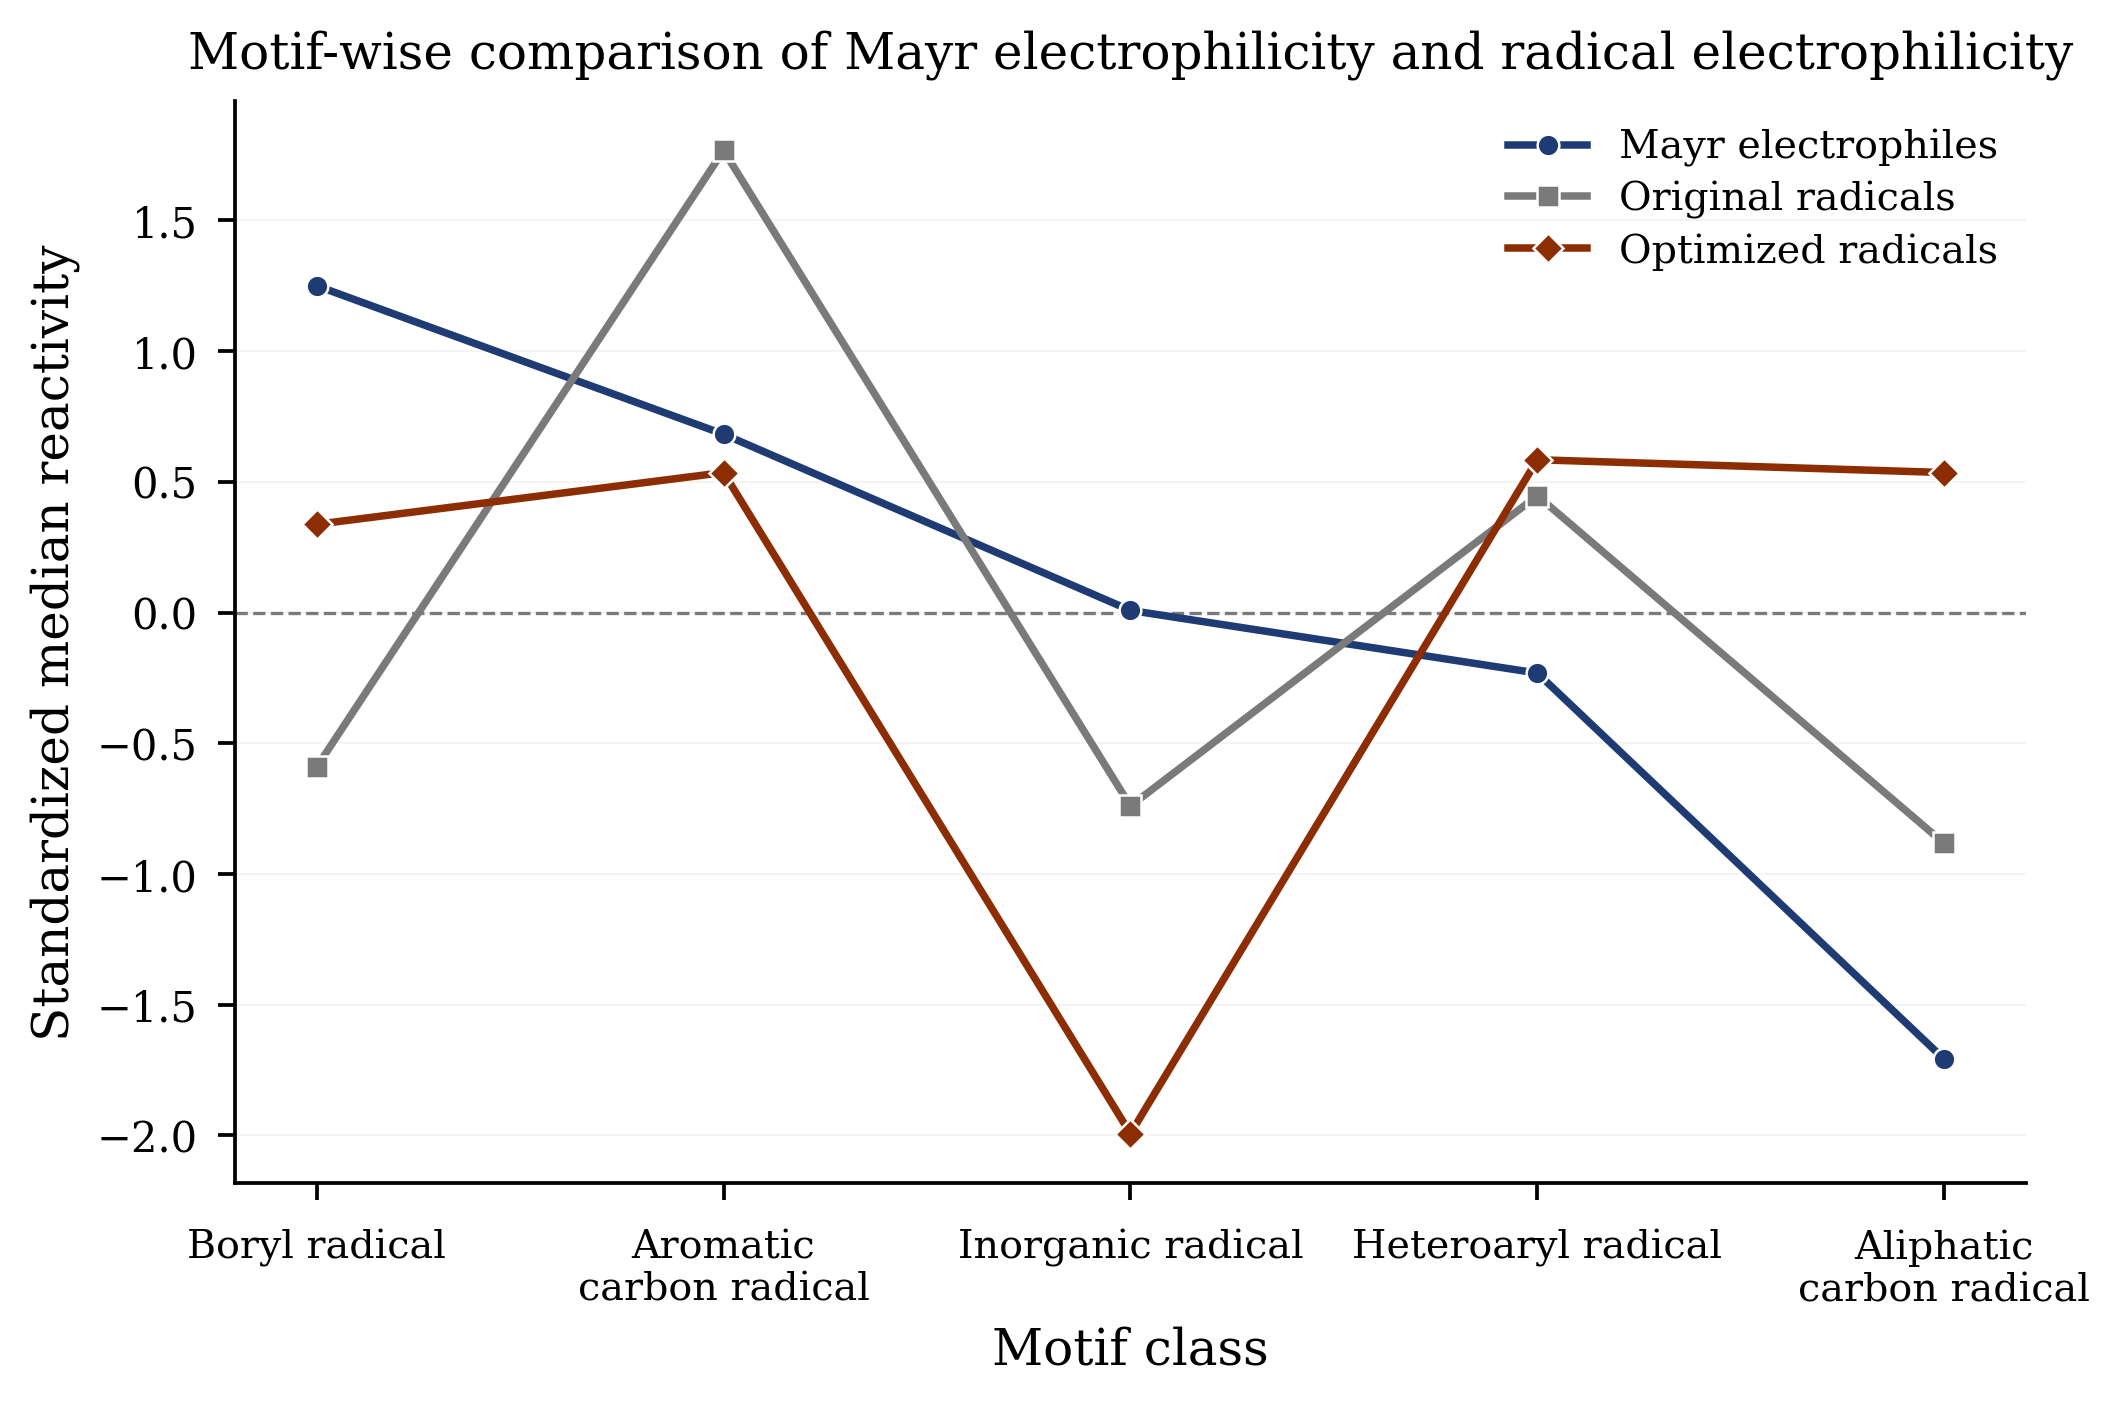

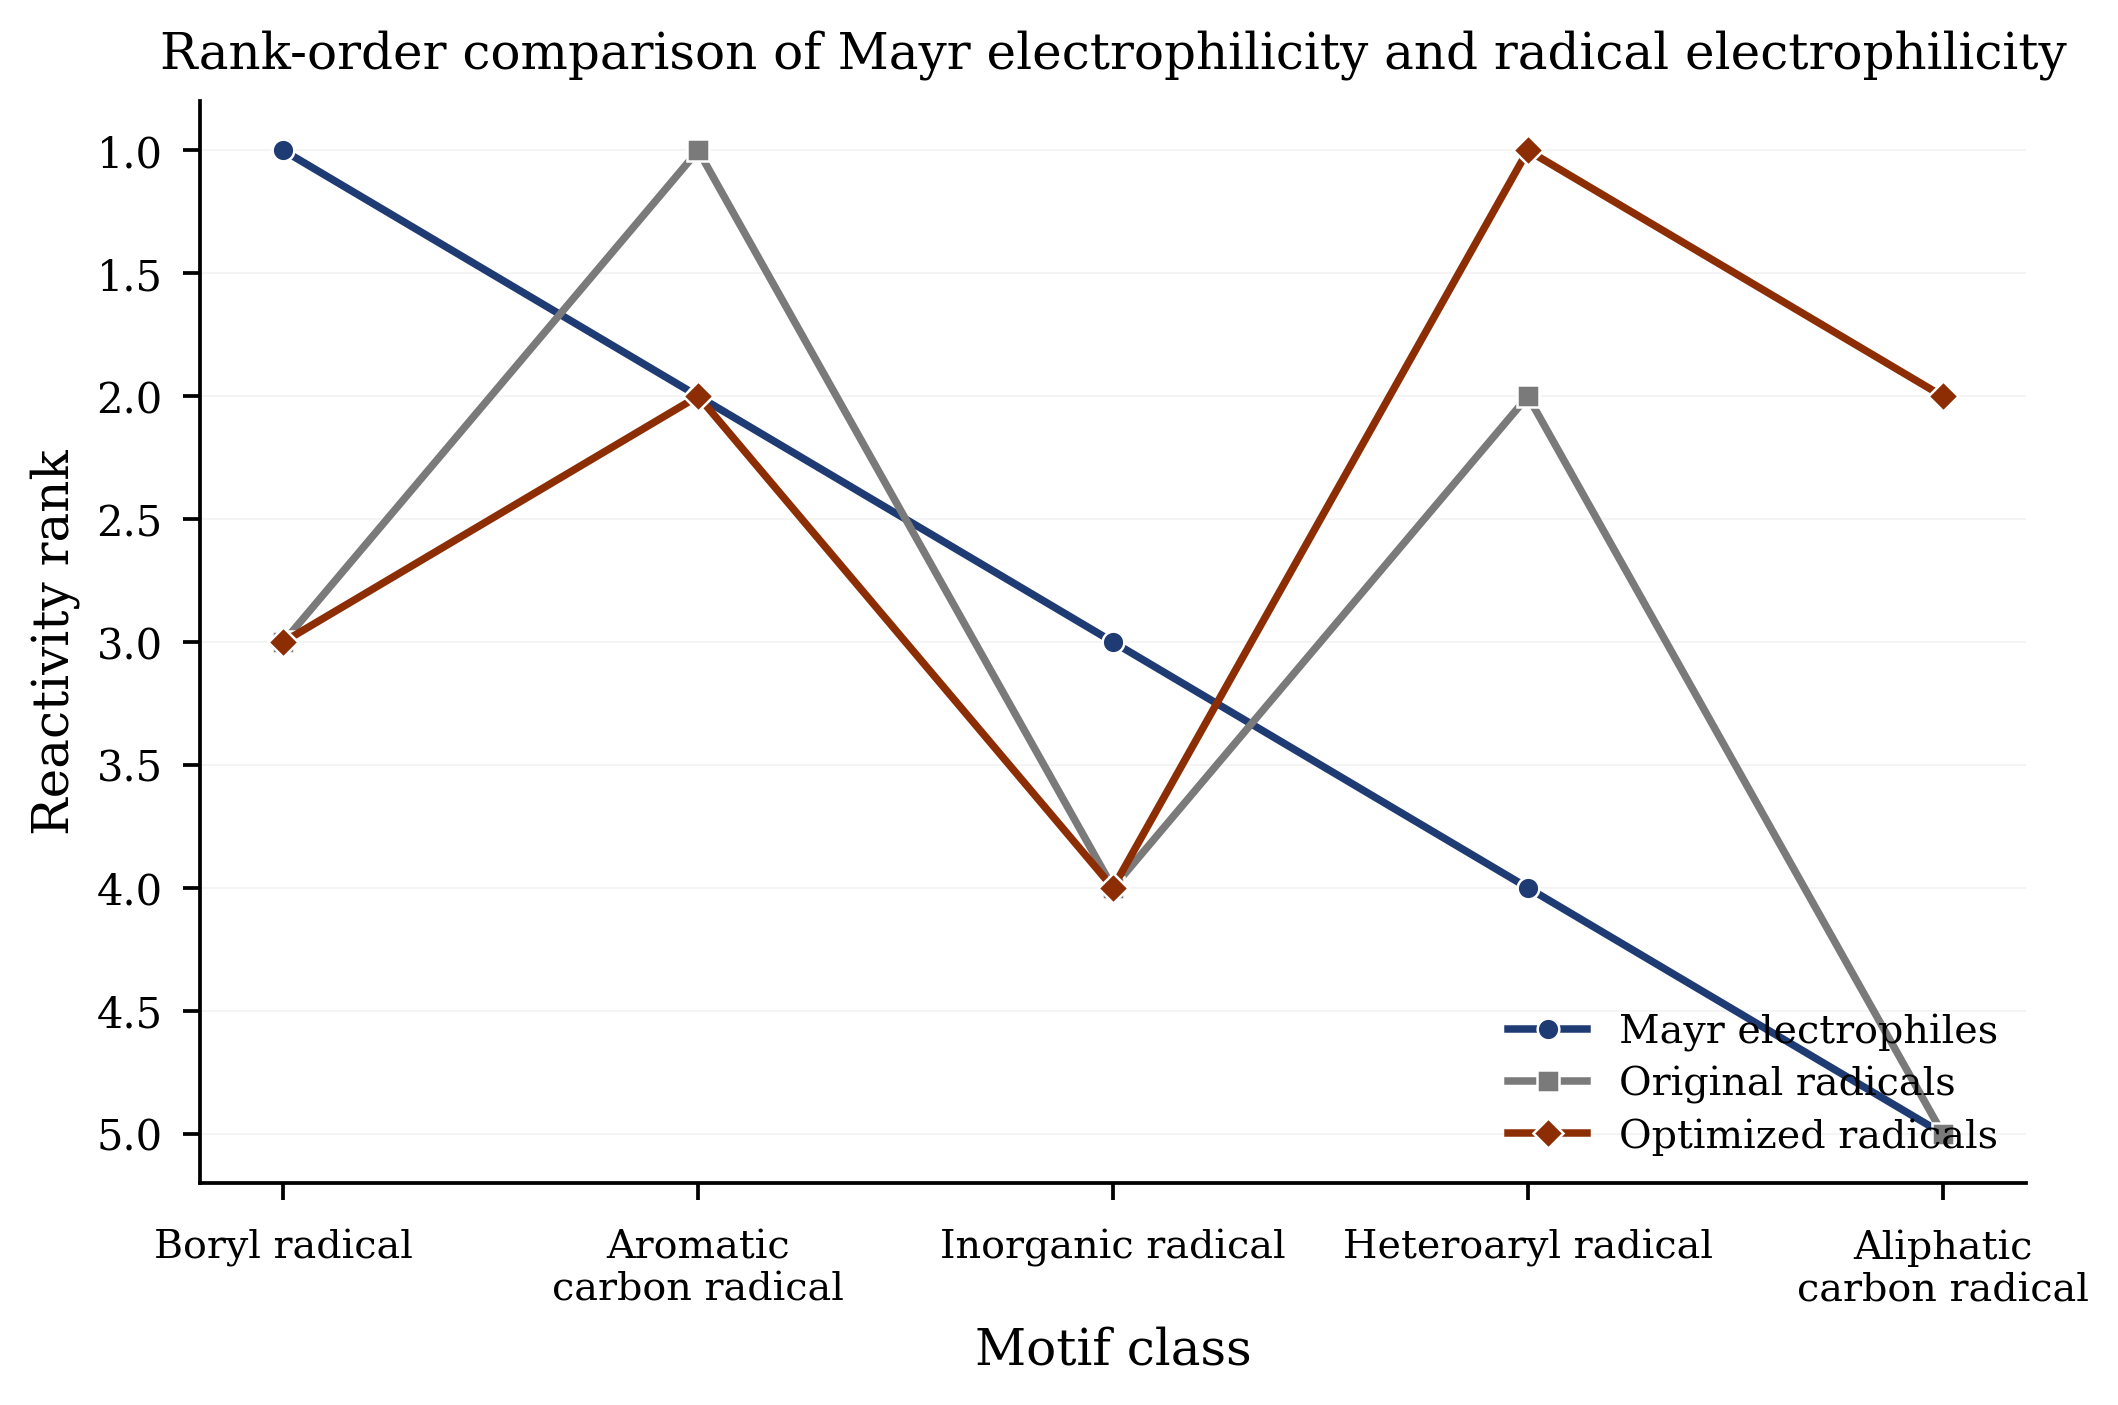

/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/Results/classwise_pattern_summary_mayrE_vs_radicalW.csv
/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/plots/pattern_comparison_mayrE_vs_original_predictedW_zscore_jctc.png
/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset/plots/pattern_comparison_mayrE_vs_original_predictedW_rank_jctc.png


In [ ]:
ßimport os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

BASE = "/content/drive/MyDrive/RL_radical_dft/RL_radical_new_dataset"
RESULTS_DIR = os.path.join(BASE, "Results")
PLOTS_DIR = os.path.join(BASE, "plots")
os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

MAYR_FILE = os.path.join(RESULTS_DIR, "mayr_electrophiles_classified_to_radical_motifs_v2_cleaned.csv")
RADICAL_CLASS_FILE = os.path.join(BASE, "dataset", "Radical_Name_List-2.xlsx")
RL_FILE = os.path.join(RESULTS_DIR, "pre_post_electronic_structure_overall_model.csv")

plt.rcParams.update({
    "figure.dpi": 300,
    "savefig.dpi": 800,
    "font.family": "serif",
    "font.serif": ["Times New Roman", "Times", "DejaVu Serif"],
    "font.size": 10.5,
    "axes.labelsize": 12,
    "axes.titlesize": 12,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 10,
    "legend.fontsize": 9.5,
    "axes.linewidth": 0.9,
    "xtick.major.width": 0.9,
    "ytick.major.width": 0.9,
    "xtick.major.size": 4,
    "ytick.major.size": 4,
    "xtick.direction": "out",
    "ytick.direction": "out",
    "mathtext.fontset": "dejavuserif",
})

COL_MAYR = "#1f3b73"
COL_ORIG = "#7a7a7a"
COL_PRED = "#8c2d04"

def zscore_col(s):
    s = pd.Series(s, dtype=float)
    sd = s.std(ddof=0)
    if sd == 0 or np.isnan(sd):
        return np.zeros(len(s))
    return (s - s.mean()) / sd

def prettify_label(label):
    return str(label).replace("_", " ").strip()

def wrap_two_lines(label):
    words = prettify_label(label).split()
    if len(words) <= 2:
        return " ".join(words)
    split_idx = len(words) // 2
    if len(words) >= 4:
        left = words[:split_idx]
        right = words[split_idx:]
    else:
        left = words[:1]
        right = words[1:]
    return " ".join(left) + "\n" + " ".join(right)

def make_two_row_labels(labels):
    return [wrap_two_lines(x) for x in labels]

def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_linewidth(0.9)
    ax.spines["bottom"].set_linewidth(0.9)
    ax.tick_params(axis="x", pad=7)
    ax.tick_params(axis="y", pad=5)
    ax.grid(axis="y", linestyle="-", linewidth=0.45, alpha=0.14)
    ax.set_axisbelow(True)

def draw_series(ax, x, y, color, marker, label):
    ax.plot(
        x, y,
        color=color,
        linewidth=1.8,
        marker=marker,
        markersize=5.2,
        markerfacecolor=color,
        markeredgecolor="white",
        markeredgewidth=0.6,
        label=label,
        zorder=3
    )

mayr = pd.read_csv(MAYR_FILE)
rad_class = pd.read_excel(RADICAL_CLASS_FILE)
rl = pd.read_csv(RL_FILE)

mayr.columns = [c.strip() for c in mayr.columns]
rad_class.columns = [c.strip() for c in rad_class.columns]
rl.columns = [c.strip() for c in rl.columns]

mayr["compound"] = mayr["compound"].astype(str).str.strip()
rad_class["Radical name"] = rad_class["Radical name"].astype(str).str.strip()
rad_class["Classification"] = rad_class["Classification"].astype(str).str.strip()
rl["Radical name"] = rl["Radical name"].astype(str).str.strip()

if "mapped_motif_final" in mayr.columns:
    mayr_motif_col = "mapped_motif_final"
elif "mapped_motif_v2" in mayr.columns:
    mayr_motif_col = "mapped_motif_v2"
elif "mapped_motif" in mayr.columns:
    mayr_motif_col = "mapped_motif"
else:
    raise ValueError(f"No mapped motif column found in Mayr file. Columns: {list(mayr.columns)}")

mayr[mayr_motif_col] = mayr[mayr_motif_col].astype(str).str.strip()

required_cols = ["Radical name", "omega_pre", "omega_post"]
missing = [c for c in required_cols if c not in rl.columns]
if missing:
    raise ValueError(f"Missing required RL columns: {missing}\nAvailable columns: {list(rl.columns)}")

rad = rl.merge(
    rad_class[["Radical name", "Classification"]].drop_duplicates(),
    on="Radical name",
    how="left"
)

rad = rad.dropna(subset=["Classification"]).copy()

label_map = {}

mayr["motif_norm"] = mayr[mayr_motif_col].replace(label_map)
rad["motif_norm"] = rad["Classification"].replace(label_map)

common_classes = sorted(set(mayr["motif_norm"]) & set(rad["motif_norm"]))

mayr = mayr[mayr["motif_norm"].isin(common_classes)].copy()
rad = rad[rad["motif_norm"].isin(common_classes)].copy()

mayr_summary = (
    mayr.groupby("motif_norm", as_index=False)
        .agg(
            Mayr_E_median=("E_param", "median"),
            Mayr_n=("E_param", "size")
        )
)

rad_summary = (
    rad.groupby("motif_norm", as_index=False)
       .agg(
           omega_original_median=("omega_pre", "median"),
           omega_predicted_median=("omega_post", "median"),
           radical_n=("omega_pre", "size")
       )
)

summary = mayr_summary.merge(rad_summary, on="motif_norm", how="inner")

summary["Mayr_E_z"] = zscore_col(summary["Mayr_E_median"])
summary["omega_original_z"] = zscore_col(summary["omega_original_median"])
summary["omega_predicted_z"] = zscore_col(summary["omega_predicted_median"])

summary = summary.sort_values("Mayr_E_z", ascending=False).reset_index(drop=True)
summary["motif_label"] = make_two_row_labels(summary["motif_norm"])

summary_path = os.path.join(RESULTS_DIR, "classwise_pattern_summary_mayrE_vs_radicalW.csv")
summary.to_csv(summary_path, index=False)

x = np.arange(len(summary))

fig, ax = plt.subplots(figsize=(7.2, 4.8))
draw_series(ax, x, summary["Mayr_E_z"], COL_MAYR, "o", "Mayr electrophiles")
draw_series(ax, x, summary["omega_original_z"], COL_ORIG, "s", "Original radicals")
draw_series(ax, x, summary["omega_predicted_z"], COL_PRED, "D", "Optimized radicals")

ax.axhline(0, linestyle="--", linewidth=0.8, color="black", alpha=0.5, zorder=1)

ax.set_xticks(x)
ax.set_xticklabels(summary["motif_label"], rotation=0, ha="center")
ax.set_ylabel("Standardized median reactivity")
ax.set_xlabel("Motif class")
ax.set_title("Motif-wise comparison of Mayr electrophilicity and radical electrophilicity", pad=8)

style_axis(ax)
ax.legend(frameon=False, loc="upper right", handlelength=2.0, borderpad=0.2, labelspacing=0.35)
fig.tight_layout()

plot1_path = os.path.join(PLOTS_DIR, "pattern_comparison_mayrE_vs_original_predictedW_zscore_jctc.png")
plt.savefig(plot1_path, bbox_inches="tight")
plt.show()

summary["Mayr_rank"] = summary["Mayr_E_median"].rank(ascending=False, method="dense")
summary["omega_original_rank"] = summary["omega_original_median"].rank(ascending=False, method="dense")
summary["omega_predicted_rank"] = summary["omega_predicted_median"].rank(ascending=False, method="dense")

fig, ax = plt.subplots(figsize=(7.2, 4.8))
draw_series(ax, x, summary["Mayr_rank"], COL_MAYR, "o", "Mayr electrophiles")
draw_series(ax, x, summary["omega_original_rank"], COL_ORIG, "s", "Original radicals")
draw_series(ax, x, summary["omega_predicted_rank"], COL_PRED, "D", "Optimized radicals")

ax.set_xticks(x)
ax.set_xticklabels(summary["motif_label"], rotation=0, ha="center")
ax.set_ylabel("Reactivity rank")
ax.set_xlabel("Motif class")
ax.set_title("Rank-order comparison of Mayr electrophilicity and radical electrophilicity", pad=8)

ax.invert_yaxis()
style_axis(ax)
ax.legend(frameon=False, loc="lower right", handlelength=2.0, borderpad=0.2, labelspacing=0.35)
fig.tight_layout()

plot2_path = os.path.join(PLOTS_DIR, "pattern_comparison_mayrE_vs_original_predictedW_rank_jctc.png")
plt.savefig(plot2_path, bbox_inches="tight")
plt.show()

print(summary_path)
print(plot1_path)
print(plot2_path)